In [53]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, welch


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [54]:
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI1_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"
RI1_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"
RI2_1_1_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"
RI1_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"
RI2_1_2_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"
RI1_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"
RI2_2_4_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"
RI2_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"
RI1_3_5_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"

ri1_h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI1_4_7": RI1_4_7_h5_path,  
    "RI1_2_3": RI1_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI1_1_1": RI1_1_1_h5_path,
    "RI1_1_2": RI1_1_2_h5_path,
    "RI1_2_4": RI1_2_4_h5_path,
    "RI1_3_5": RI1_3_5_h5_path,
}

ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
    "RI2_1_1": RI2_1_1_h5_path,
    "RI2_1_2": RI2_1_2_h5_path,
    "RI2_2_4": RI2_2_4_h5_path,
    "RI2_3_5": RI2_3_5_h5_path,
}


In [55]:
# Choose one by key
key = "RI1_3_6"   # change to whichever you want to test
h5_file = ri1_h5_paths[key]

print("Using:", h5_file)
print("Exists?", os.path.exists(h5_file))


Using: E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5
Exists? True


In [56]:
with h5py.File(h5_file, 'r') as f:
    print("Top-level keys:", list(f.keys()))


Top-level keys: ['ekg', 'ekg_metadata', 'metadata', 'resp', 'resp_metadata']


In [57]:
with h5py.File(h5_file, 'r') as f:
    # Try common places for fs
    fs = None

    # resp dataset attrs?
    if 'resp' in f:
        print("resp attrs:", dict(f['resp'].attrs))
        for k in ['sampling_rate','fs','rate','Fs','FS']:
            if k in f['resp'].attrs:
                fs = float(f['resp'].attrs[k])

    # metadata groups?
    for grp in ['resp_metadata','ekg_metadata','metadata','info']:
        if grp in f:
            print(f"{grp} attrs:", dict(f[grp].attrs))
            # fs directly?
            for k in ['sampling_rate','fs','rate','Fs','FS']:
                if k in f[grp].attrs and fs is None:
                    fs = float(f[grp].attrs[k])
            # or via duration
            if fs is None and 'duration_sec' in f[grp].attrs and 'resp' in f:
                dur = float(f[grp].attrs['duration_sec'])
                if dur > 0:
                    resp_len = len(f['resp'][:])
                    fs = resp_len / dur

print("Detected fs:", fs)


resp attrs: {}
resp_metadata attrs: {}
ekg_metadata attrs: {'channel_id': '21', 'duration_sec': 603.2723, 'num_samples': 12065446, 'sampling_frequency': 20000.0, 'stream_id': 'trodes'}
metadata attrs: {'date': '2025-06-21', 'negative_agent_id': 'RB3', 'positive_agent_id': '5.3', 'subject_id': '3.6', 'time': '12:53:12', 'trial_type': 'RI1'}
Detected fs: 20000.0


In [58]:
with h5py.File(h5_file, 'r') as f:
    resp = f['resp'][:].astype(float).flatten()

fs = 20000.0  # from ekg_metadata.sampling_frequency
dur_from_len = len(resp) / fs
print("len(resp):", len(resp))
print("fs (Hz):", fs)
print("duration from length (s):", dur_from_len)


len(resp): 12065446
fs (Hz): 20000.0
duration from length (s): 603.2723


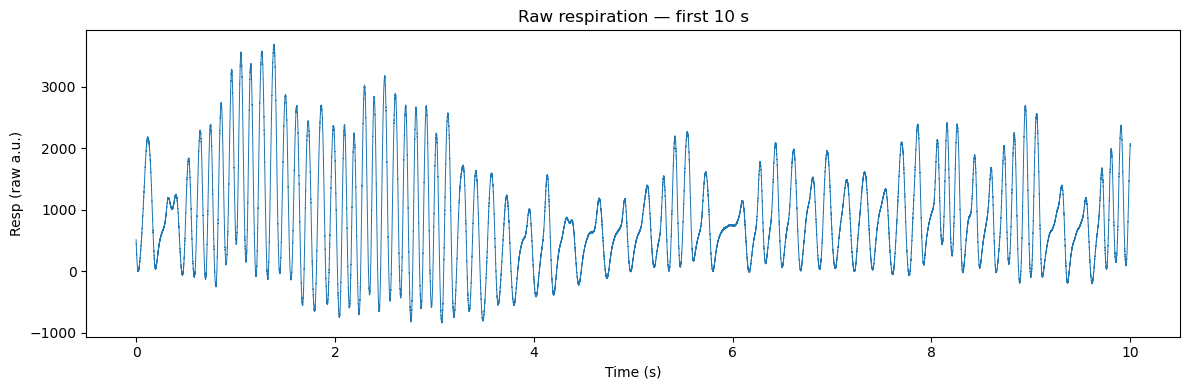

In [59]:
T = 10  # seconds
N = int(min(len(resp), fs*T))
t = np.arange(N) / fs

plt.figure(figsize=(12,4))
plt.plot(t, resp[:N], lw=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Resp (raw a.u.)")
plt.title("Raw respiration — first 10 s")
plt.tight_layout()
plt.show()


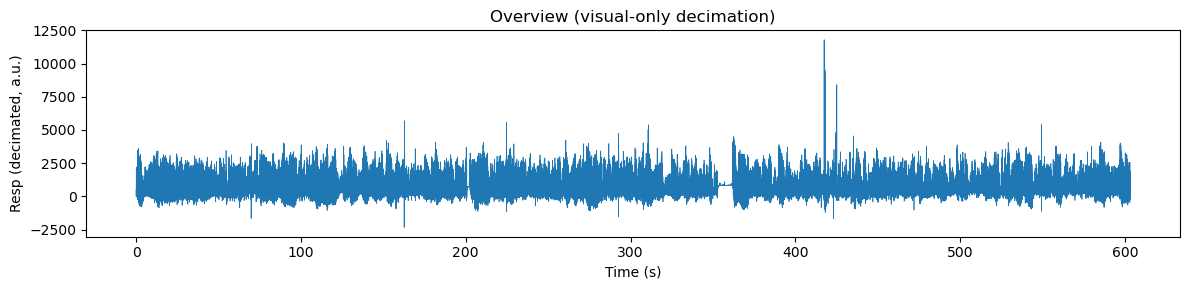

In [60]:
step = int(fs // 50)  # ~50 Hz view; for visualization ONLY
vis = resp[::step]
t_vis = np.arange(len(vis)) * (step / fs)

plt.figure(figsize=(12,3))
plt.plot(t_vis, vis, lw=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Resp (decimated, a.u.)")
plt.title("Overview (visual-only decimation)")
plt.tight_layout()
plt.show()


In [102]:
# 1) Anti-alias low-pass at 40 Hz BEFORE downsampling
#    (New Nyquist after DS to 100 Hz is 50 Hz, so 40 Hz is a safe guard band.)
b_lp, a_lp = butter(N=4, Wn=40.0/(fs/2), btype='low')
resp_aa = filtfilt(b_lp, a_lp, resp)   # zero-phase: no lag distortion

# 2) Downsample 20000 Hz -> ~100 Hz (use round in case fs isn't exact)
down = int(round(fs / 100.0))          # 200 for fs=20000
resp_ds = resample_poly(resp_aa, up=1, down=down)
fs_ds = fs / down                      # ≈100.0 Hz

# 3) Band-pass 0.5–15 Hz on the downsampled signal (breathing band)
b_bp, a_bp = butter(N=4, Wn=[0.5/(fs_ds/2), 15.0/(fs_ds/2)], btype='bandpass')
resp_f = filtfilt(b_bp, a_bp, resp_ds) # zero-phase again

print("Original fs:", fs, "-> Downsampled fs:", fs_ds)
print("Lengths:", len(resp), "->", len(resp_f))


Original fs: 20000.0 -> Downsampled fs: 100.0
Lengths: 12065446 -> 60328


Dominant frequency: 9.80 Hz
Power fraction 6–12 Hz: 77.5%
Power fraction 1–4 Hz:  9.0%


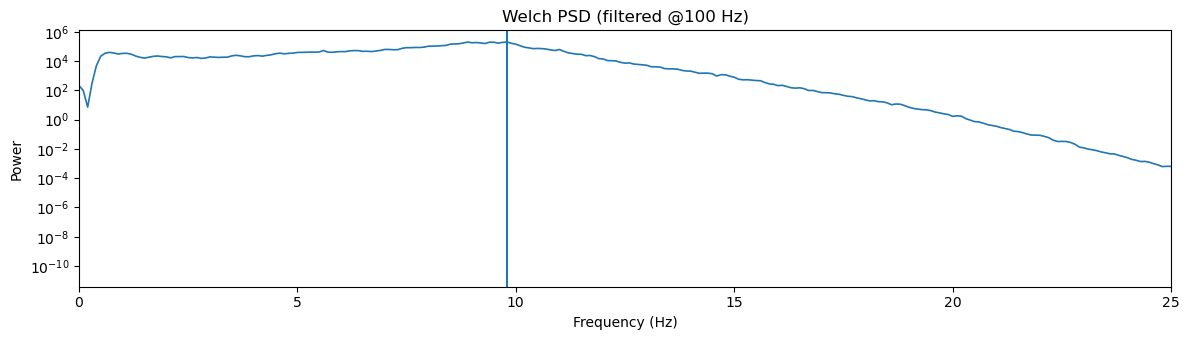

In [106]:
# PSD on filtered @100 Hz signal
nper = int(fs_ds*10)   # ~10 s windows for ~0.1 Hz resolution
f, pxx = welch(resp_f, fs=fs_ds, nperseg=nper, noverlap=nper//2, detrend='constant')

# Bands
resp_band = (f >= 0.5) & (f <= 15)
sniff_band = (f >= 6) & (f <= 12)
basal_band = (f >= 1) & (f <= 4)

# Dominant frequency within respiration band
f_peak = f[resp_band][np.argmax(pxx[resp_band])]

# Power fractions
total_power = pxx[resp_band].sum()
sniff_frac  = (pxx[sniff_band].sum() / total_power) if total_power > 0 else np.nan
basal_frac  = (pxx[basal_band].sum() / total_power) if total_power > 0 else np.nan

print(f"Dominant frequency: {f_peak:.2f} Hz")
print(f"Power fraction 6–12 Hz: {sniff_frac:.1%}")
print(f"Power fraction 1–4 Hz:  {basal_frac:.1%}")

# Plot with a marker at the peak (colors are optional; remove if you prefer defaults)
plt.figure(figsize=(12,3.5))
plt.semilogy(f, pxx, lw=1.2)
plt.axvline(f_peak)  # marks the dominant freq
plt.xlim(0, 25)
plt.xlabel("Frequency (Hz)"); plt.ylabel("Power")
plt.title("Welch PSD (filtered @100 Hz)")
plt.tight_layout(); plt.show()


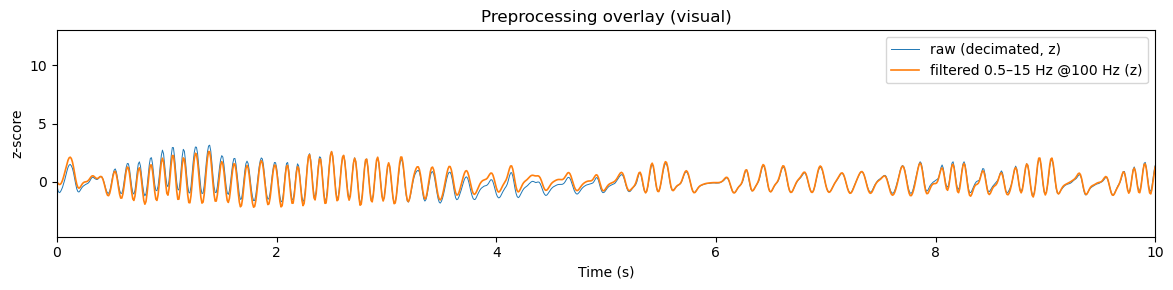

In [107]:
# Raw (resp, fs) and processed (resp_f, fs_ds) must already exist
# Make step safe even if fs≈fs_ds
step = max(1, int(round(fs / fs_ds)))           # ~fs_ds view; VISUAL ONLY

raw_vis = resp[::step][:len(resp_f)]            # match length to filtered
t = np.arange(len(resp_f)) / fs_ds              # time axis in seconds

# z-score helper so amplitudes are comparable
def z(x): 
    x = np.asarray(x)
    return (x - x.mean()) / (x.std() + 1e-12)

plt.figure(figsize=(12,3))
plt.plot(t, z(raw_vis), lw=0.7, label='raw (decimated, z)')
plt.plot(t, z(resp_f),  lw=1.2, label='filtered 0.5–15 Hz @100 Hz (z)')
plt.xlim(0, 10)                                  # change to (30,40) for a different window
plt.xlabel("Time (s)"); plt.ylabel("z-score")
plt.title("Preprocessing overlay (visual)")
plt.legend(); plt.tight_layout(); plt.show()


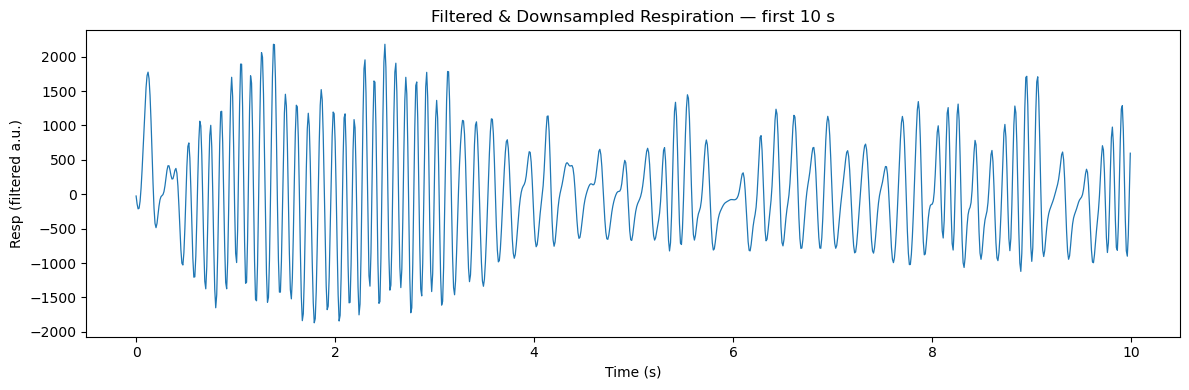

In [108]:
T = 10
N = int(min(len(resp_f), fs_ds*T))
t_ds = np.arange(N) / fs_ds

plt.figure(figsize=(12,4))
plt.plot(t_ds, resp_f[:N], lw=0.9)
plt.xlabel("Time (s)")
plt.ylabel("Resp (filtered a.u.)")
plt.title("Filtered & Downsampled Respiration — first 10 s")
plt.tight_layout()
plt.show()


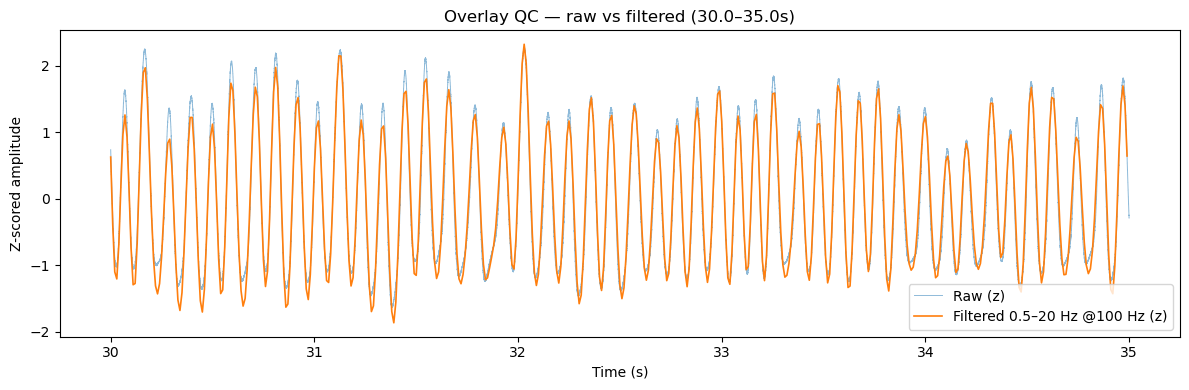

In [109]:
# choose a clean segment
seg_start_s = 30.0
seg_dur_s   = 5.0

# indices in raw (20 kHz)
i0_raw = int(seg_start_s * fs)
i1_raw = int((seg_start_s + seg_dur_s) * fs)

# indices in filtered (100 Hz)
i0_ds = int(seg_start_s * fs_ds)
i1_ds = int((seg_start_s + seg_dur_s) * fs_ds)

# time vectors
t_raw = np.arange(i0_raw, i1_raw) / fs
t_flt = np.arange(i0_ds,  i1_ds)  / fs_ds

# grab segments
x_raw = resp[i0_raw:i1_raw].astype(float)
x_flt = resp_f[i0_ds:i1_ds].astype(float)

# z-score each segment (so amplitudes are comparable)
def zscore(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-12)
x_raw_z = zscore(x_raw)
x_flt_z = zscore(x_flt)

plt.figure(figsize=(12,4))
plt.plot(t_raw, x_raw_z, alpha=0.5, lw=0.7, label="Raw (z)")
plt.plot(t_flt, x_flt_z, lw=1.2, label="Filtered 0.5–20 Hz @100 Hz (z)")
plt.xlabel("Time (s)")
plt.ylabel("Z-scored amplitude")
plt.title(f"Overlay QC — raw vs filtered ({seg_start_s}–{seg_start_s+seg_dur_s}s)")
plt.legend()
plt.tight_layout()
plt.show()


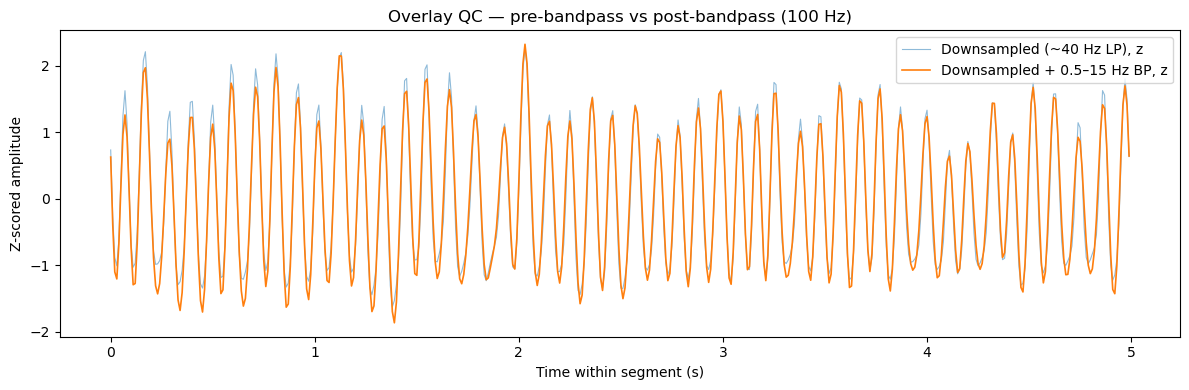

In [110]:
# If you want to see only the effect of the band-pass on the downsampled signal:
# segments in the 100 Hz domain (same indices you used earlier)
x_ds   = resp_ds[i0_ds:i1_ds].astype(float)   # AA low-pass + downsampled (no BP)
x_filt = resp_f[i0_ds:i1_ds].astype(float)    # + band-pass 0.5–15 Hz

# z-score (visual comparability only)
def zscore(x):
    return (x - x.mean()) / (x.std() + 1e-12)
x_ds_z   = zscore(x_ds)
x_filt_z = zscore(x_filt)

# local time axis (0 → segment duration)
t_local = np.arange(len(x_ds)) / fs_ds

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(t_local, x_ds_z,   alpha=0.5, lw=0.8, label="Downsampled (~40 Hz LP), z")
plt.plot(t_local, x_filt_z, lw=1.2,     label="Downsampled + 0.5–15 Hz BP, z")
plt.xlabel("Time within segment (s)")
plt.ylabel("Z-scored amplitude")
plt.title("Overlay QC — pre-bandpass vs post-bandpass (100 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
# Use the filtered, ~100 Hz signal
sig = resp_f
Fs  = fs_ds

# Helper (robust spread); define if not already present
def robust_std(x):
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

# Physiology-aware constraints
MAX_RATE_HZ = 12.0                 # cap (sniff ceiling)
min_ibi_s   = 1.0 / MAX_RATE_HZ    # >= 0.083 s between breaths
max_ibi_s   = 2.0                  # <= 2.0 s (0.5 Hz)

# Peak finder settings
min_distance = int(np.floor(Fs / MAX_RATE_HZ))  # samples for ≥0.083 s spacing
min_width    = int(Fs * 0.03)                   # ≥30 ms width
prominence   = 0.5 * robust_std(sig)            # must stand out from neighbors

# >>> Detect INHALE PEAKS (NOT troughs)
inh_idx2, props2 = find_peaks(
    sig,
    distance=min_distance,
    width=min_width,
    prominence=prominence
)

print("Detected inhale peaks:", len(inh_idx2))

Detected inhale peaks: 4259


In [116]:
# assumes: trough_idx (from find_peaks on -resp_f), Fs = fs_ds = 100.0
import numpy as np

ibi_s = np.diff(trough_idx) / Fs
print("IBI secs  [min, p5, p25, median, p75, p95, max]:",
      [float(x) for x in np.nanpercentile(ibi_s, [0,5,25,50,75,95,100])])

rate_hz = 1.0 / ibi_s
print("Rate Hz   [min, p5, p25, median, p75, p95, max]:",
      [float(x) for x in np.nanpercentile(rate_hz, [0,5,25,50,75,95,100])])

# fraction of implausible IBIs
too_short = (ibi_s < 0.06).mean()  # > ~16.7 Hz
too_long  = (ibi_s > 2.0).mean()   # < 0.5 Hz
print(f"Fraction IBI < 0.06 s: {too_short:.3%}   |   IBI > 2.0 s: {too_long:.3%}")


IBI secs  [min, p5, p25, median, p75, p95, max]: [0.07, 0.09, 0.1, 0.11, 0.15, 0.28, 9.31]
Rate Hz   [min, p5, p25, median, p75, p95, max]: [0.10741138560687433, 3.571428571428571, 6.666666666666667, 9.090909090909092, 10.0, 11.11111111111111, 14.285714285714285]
Fraction IBI < 0.06 s: 0.000%   |   IBI > 2.0 s: 0.023%


In [117]:
# Instantaneous rate from inter-peak intervals, keep within [min_ibi_s, max_ibi_s]
ibi = np.diff(inh_idx2) / Fs
ok  = (ibi >= min_ibi_s) & (ibi <= max_ibi_s)

t_rate2  = inh_idx2[1:][ok] / Fs     # time (s) for each rate sample
rate_hz2 = 1.0 / ibi[ok]             # Hz

# Quick summary
if len(rate_hz2):
    q = np.percentile(rate_hz2, [25, 50, 75]).round(2)
    print(f"Breaths kept for rate: {len(rate_hz2)}/{len(ibi)}")
    print("Rate Hz [p25, median, p75]:", q.tolist())
    print("Fraction > 6 Hz:", float((rate_hz2 > 6).mean()))
else:
    print("No valid IBIs after constraints; consider lowering prominence or width slightly.")

Breaths kept for rate: 4256/4258
Rate Hz [p25, median, p75]: [6.67, 9.09, 10.0]
Fraction > 6 Hz: 0.8080357142857143


In [118]:
# Filtered, downsampled respiration
sig = resp_f
Fs  = fs_ds  # 100 Hz

def robust_std(x):
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

# Constraints tuned for inhale PEAKS
min_distance = int(Fs * 0.09)   # ≥ 90 ms between peaks (~≤ 11.1 Hz)
prominence   = 0.5 * robust_std(sig)
min_width    = int(Fs * 0.03)   # ≥ 30 ms width at half-prominence

# Detect INHALATION PEAKS (no inversion)
inh_idx2, props2 = find_peaks(
    sig,
    distance=min_distance,
    prominence=prominence,
    width=min_width
)

old_peaks = len(inh_idx) if 'inh_idx' in locals() else 'N/A'
print(f"Old peaks: {old_peaks} | New peaks: {len(inh_idx2)}")


Old peaks: 3789 | New peaks: 4181


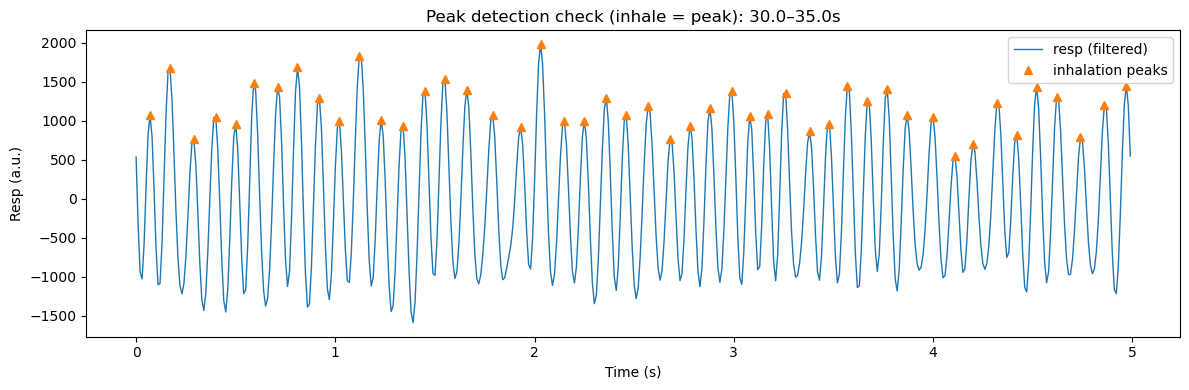

In [119]:
# --- Peak detection check (inhale = peak) ---

sig = resp_f
Fs  = fs_ds  # 100 Hz

seg_start_s = 30.0
seg_dur_s   = 5.0

i0 = int(seg_start_s * Fs)
i1 = min(int((seg_start_s + seg_dur_s) * Fs), len(sig))

# local time vector matches the slice length exactly
t_local = np.arange(i1 - i0) / Fs

plt.figure(figsize=(12,4))
plt.plot(t_local, sig[i0:i1], lw=1.0, label="resp (filtered)")

# plot INHALATION PEAKS if available
if 'inh_idx2' in locals():
    mask = (inh_idx2 >= i0) & (inh_idx2 < i1)
    if np.any(mask):
        plt.plot((inh_idx2[mask] - i0) / Fs, sig[inh_idx2[mask]],
                 '^', ms=6, label="inhalation peaks")
else:
    print("Note: 'inh_idx2' not found. Run the peak detection cell first.")

plt.xlabel("Time (s)")
plt.ylabel("Resp (a.u.)")
plt.title(f"Peak detection check (inhale = peak): {seg_start_s:.1f}–{seg_start_s+seg_dur_s:.1f}s")
plt.legend()
plt.tight_layout()
plt.show()


In [120]:
# --- Inhale-peak rate with a 12 Hz cutoff -----------------------------------
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

# Inputs (already in your notebook)
sig = resp_f        # filtered respiration @ ~100 Hz
Fs  = fs_ds         # sampling rate (≈100.0)

def robust_std(x):
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

# Set the physiological cap
MAX_RATE_HZ = 12.0
min_ibi     = 1.0 / MAX_RATE_HZ                 # ~0.083 s
min_dist    = int(np.floor(Fs / MAX_RATE_HZ))   # samples between peaks (≈8 @100 Hz)
min_width   = int(Fs * 0.03)                    # >=30 ms width
prominence  = 0.5 * robust_std(sig)

# 1) Detect INHALATION PEAKS if not already available
if 'inh_idx2' not in locals():
    inh_idx2, props2 = find_peaks(
        sig,
        distance=min_dist,
        prominence=prominence,
        width=min_width
    )

# 2) Instantaneous rate from inter-peak intervals (apply same 12 Hz cap)
ibi = np.diff(inh_idx2) / Fs
valid = (ibi >= min_ibi) & (ibi <= 2.0)         # keep 0.083–2.0 s (≈12–0.5 Hz)

t_rate2   = inh_idx2[1:][valid] / Fs            # time (s) to place each rate sample
rate_hz2  = 1.0 / ibi[valid]                    # Hz

print(f"Detected inhale peaks: {len(inh_idx2)}")
print(f"Breaths kept for rate: {len(rate_hz2)} / {len(ibi)}")
print("Rate Hz [p25, median, p75]:", np.percentile(rate_hz2, [25, 50, 75]).round(2))
print("Fraction > 6 Hz:", float((rate_hz2 > 6).mean()))

# 3) (Optional) make a time-indexed series + per-minute summaries
rate_series2 = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2, unit='s')).sort_index()
if len(rate_series2):
    rate_series2.index = rate_series2.index - rate_series2.index.min()  # zero-anchor

per_min_median = rate_series2.resample('60s').median()
sniff_occ      = (rate_series2 > 6.0).resample('60s').mean()

Detected inhale peaks: 4181
Breaths kept for rate: 4178 / 4180
Rate Hz [p25, median, p75]: [ 6.67  8.33 10.  ]
Fraction > 6 Hz: 0.7893729056965055


Dominant freq Hz [p25, median, p75]: [7.5  8.75 9.5 ]


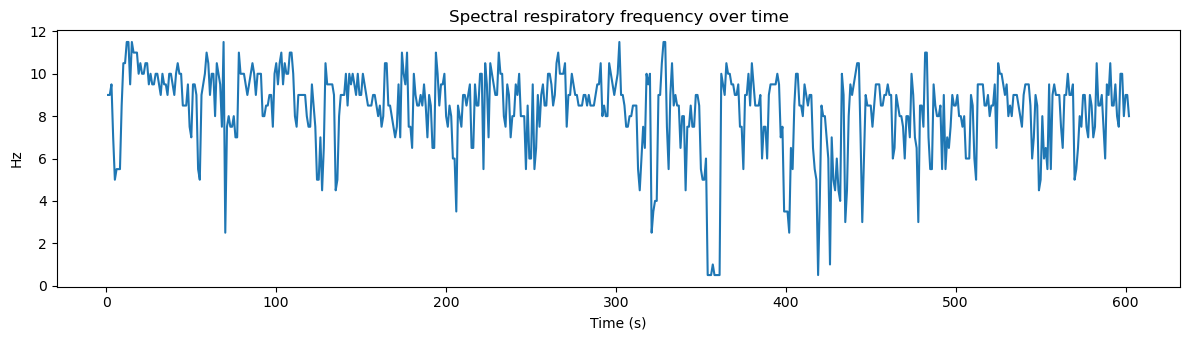

In [121]:
from scipy.signal import spectrogram
import numpy as np

# 2 s windows with 1 s overlap (smooth but responsive)
nper = int(Fs * 2.0)
nover = int(Fs * 1.0)
f, tt, Sxx = spectrogram(sig, fs=Fs, nperseg=nper, noverlap=nover,
                         scaling='density', mode='psd')

# Limit to 0.5–15 Hz band
band = (f >= 0.5) & (f <= 15.0)
f_band = f[band]
S_band = Sxx[band, :]

# Dominant frequency per window
peak_idx = np.argmax(S_band, axis=0)
dom_freq = f_band[peak_idx]  # Hz, per tt window

print("Dominant freq Hz [p25, median, p75]:",
      np.percentile(dom_freq, [25,50,75]).round(2))

# Plot spectral rate vs peak-based rate (1 s median)
plt.figure(figsize=(12,3.5))
plt.plot(tt, dom_freq, lw=1.5, label="PSD dominant freq (2s windows)")
plt.xlabel("Time (s)")
plt.ylabel("Hz")
plt.title("Spectral respiratory frequency over time")
plt.tight_layout()
plt.show()


Dominant freq Hz [p25, median, p75]: [8.  9.  9.5]
Pearson r (10 s smoothed): 0.7828712335332996


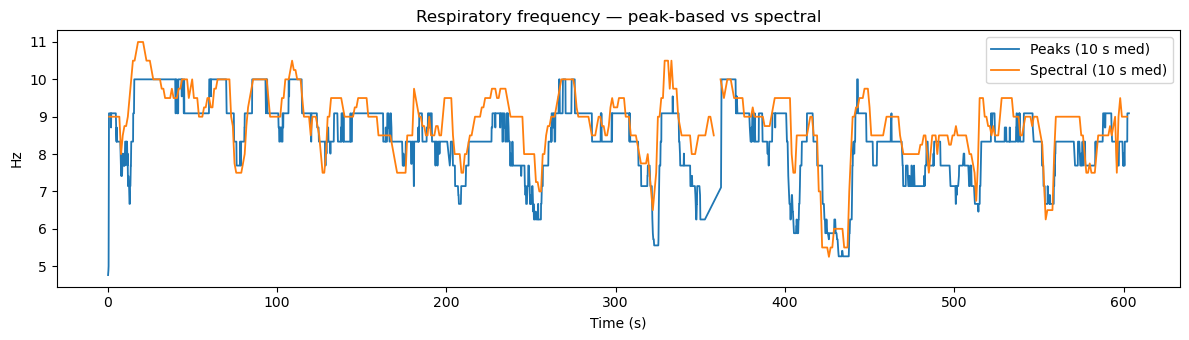

In [122]:
# Self-contained spectrogram + low-power masking + overlay with peak-based rate

from scipy.signal import spectrogram
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Inputs (filtered @100 Hz)
sig = resp_f
Fs  = fs_ds

# --- Spectrogram (2 s windows, 1 s overlap) ---
nper = int(Fs * 2.0)
nover = int(Fs * 1.0)
f, tt, Sxx = spectrogram(sig, fs=Fs, nperseg=nper, noverlap=nover,
                         scaling='density', mode='psd')

# Restrict to respiration band
band    = (f >= 0.5) & (f <= 15.0)
f_band  = f[band]
S_band  = Sxx[band, :]                 # <-- now defined
bandpow = S_band.sum(axis=0)

# Dominant frequency per window
peak_idx = np.argmax(S_band, axis=0)
dom_freq = f_band[peak_idx]

# Mask low-power windows (drop bottom 20% band power)
thr = np.percentile(bandpow, 20)
dom_mask = dom_freq.copy()
dom_mask[bandpow < thr] = np.nan

print("Dominant freq Hz [p25, median, p75]:",
      np.nanpercentile(dom_mask, [25, 50, 75]).round(2))

# --- Build Timedelta-indexed Series for plotting/comparison ---
spec_s = pd.Series(dom_mask, index=pd.to_timedelta(tt, unit='s'))

# If you have inhale PEAKS (inh_idx2), compare to peak-based rate
if 'inh_idx2' in locals():
    ibi = np.diff(inh_idx2) / Fs
    valid = (ibi >= 0.05) & (ibi <= 2.0)
    rate_hz2 = 1.0 / ibi[valid]
    t_rate2  = inh_idx2[1:][valid] / Fs
    peak_s = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2, unit='s'))

    # Smooth to 10 s, align by nearest timestamps (0.5 s tolerance), compute r
    spec10 = spec_s.rolling('10s', min_periods=1).median()
    peak10 = peak_s.rolling('10s', min_periods=1).median()

    peak10_df = peak10.sort_index().to_frame('peak').reset_index().rename(columns={'index':'t'})
    spec10_df = spec10.sort_index().to_frame('spec').reset_index().rename(columns={'index':'t'})

    df = pd.merge_asof(peak10_df, spec10_df, on='t', direction='nearest',
                       tolerance=pd.Timedelta('500ms')).dropna()

    if len(df) >= 10 and df['peak'].std() > 0 and df['spec'].std() > 0:
        print("Pearson r (10 s smoothed):", df['peak'].corr(df['spec']))

    # Overlay plot
    plt.figure(figsize=(12,3.5))
    plt.plot(peak10.index.total_seconds(), peak10.values, lw=1.3, label='Peaks (10 s med)')
    plt.plot(spec10.index.total_seconds(), spec10.values, lw=1.3, label='Spectral (10 s med)')
    plt.xlabel("Time (s)"); plt.ylabel("Hz")
    plt.title("Respiratory frequency — peak-based vs spectral")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    # Just plot spectral dominant frequency if peaks aren't available
    plt.figure(figsize=(12,3.5))
    plt.plot(tt, dom_mask, lw=1.5, label="PSD dominant freq (2 s windows)")
    plt.xlabel("Time (s)"); plt.ylabel("Hz")
    plt.title("Spectral respiratory frequency over time")
    plt.tight_layout(); plt.show()


count    11.000000
mean      8.630006
std       0.574212
min       7.692308
25%       8.333333
50%       9.090909
75%       9.090909
max       9.090909
dtype: float64


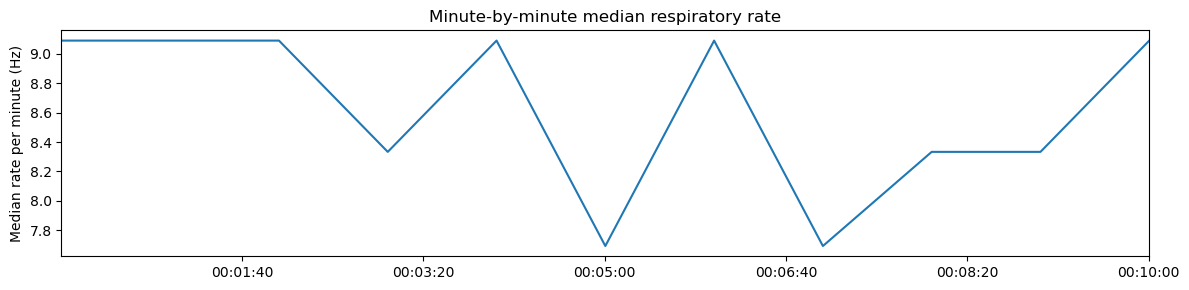

In [123]:
import pandas as pd
rate_series2 = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2, unit='s'))
per_min_median = rate_series2.resample('60s').median()

print(per_min_median.describe())
per_min_median.plot(figsize=(12,3), lw=1.5)
plt.ylabel("Median rate per minute (Hz)")
plt.title("Minute-by-minute median respiratory rate")
plt.tight_layout(); plt.show()


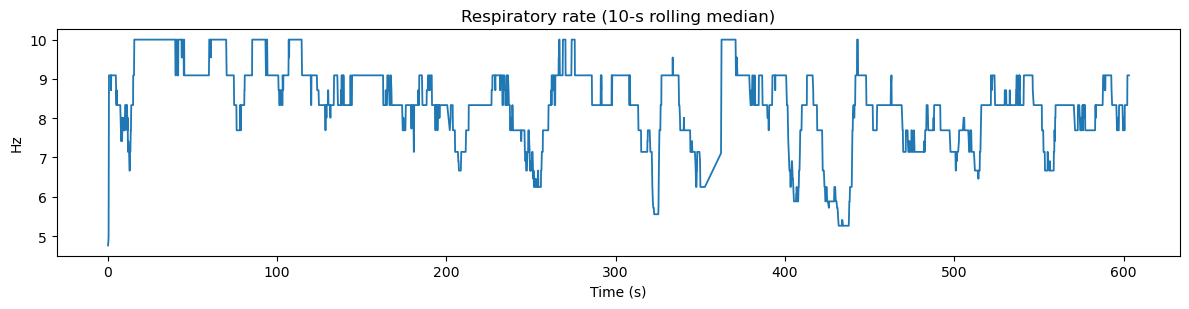

In [124]:
# uses the stricter detections: t_rate2 (s), rate_hz2 (Hz)
rate_s = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2, unit='s'))
rate10 = rate_s.rolling('10s', min_periods=1).median()

plt.figure(figsize=(12,3.2))
plt.plot(rate10.index.total_seconds(), rate10.values, lw=1.3)
plt.ylabel("Hz"); plt.xlabel("Time (s)")
plt.title("Respiratory rate (10-s rolling median)")
plt.tight_layout(); plt.show()


Fraction of time >10 Hz: 0.0%
Per-minute ventilation proxy (median) — describe():
count       11.00
mean     20513.89
std       2290.33
min      17318.58
25%      18686.89
50%      20850.41
75%      21702.71
max      24199.97
dtype: float64


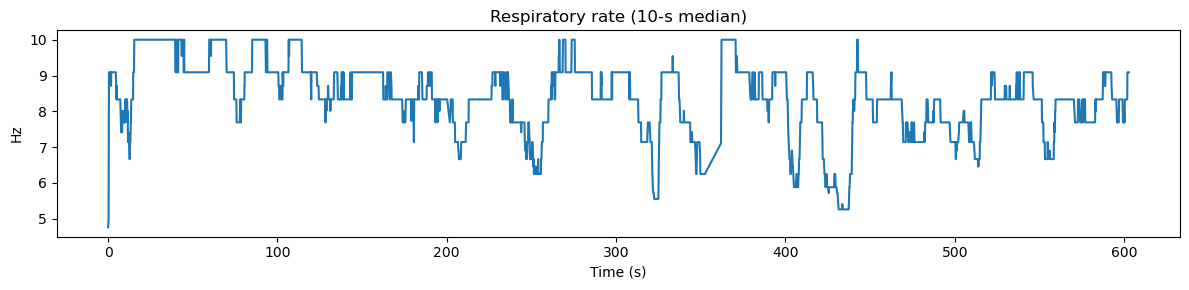

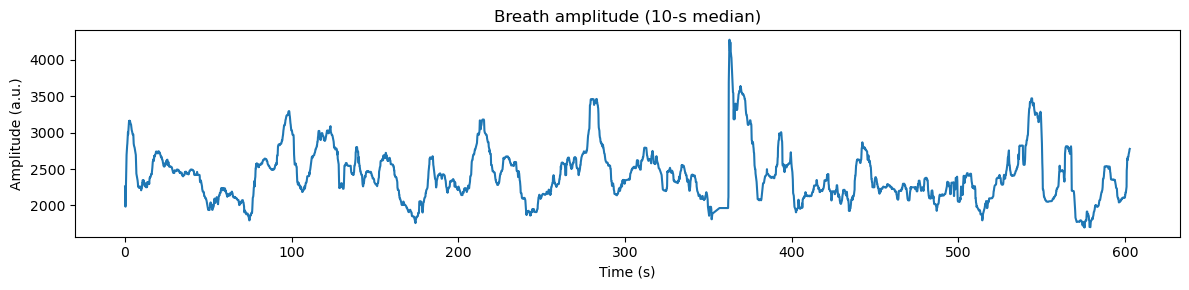

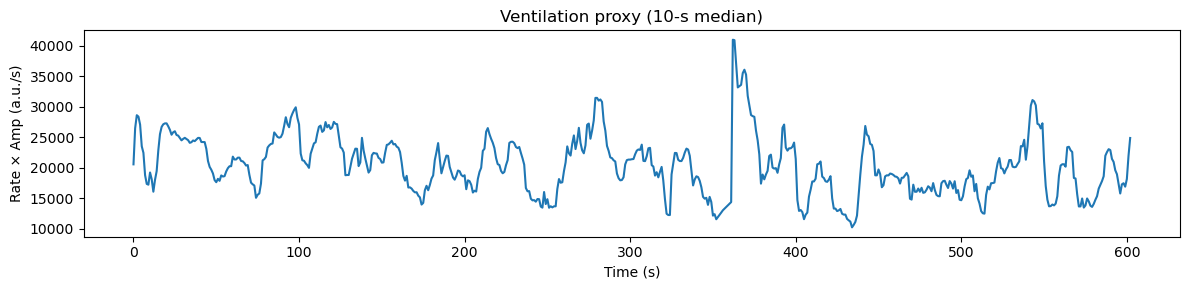

In [125]:
sig, Fs = resp_f, fs_ds

# 1) Rate series (already have)
rate_s = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2,'s')).sort_index()
rate_s.index -= rate_s.index.min()

# 2) Per-breath amplitude between consecutive inhale peaks (peak-to-trough proxy)
amps, t_amp = [], []
for i in range(1, len(inh_idx2)):
    a, b = inh_idx2[i-1], inh_idx2[i]
    seg = sig[a:b]
    if len(seg) >= 3:
        amps.append(seg.max() - seg.min())   # peak-to-trough within the breath
        t_amp.append(b / Fs)                 # assign to time of the 2nd peak
amp_s = pd.Series(amps, index=pd.to_timedelta(t_amp,'s')).sort_index()
amp_s.index -= amp_s.index.min()

# 3) Smooth to 10 s for a fair comparison
rate10 = rate_s.rolling('10s', min_periods=1).median()
amp10  = amp_s.rolling('10s', min_periods=1).median()

# 4) Ventilation proxy = rate × amplitude (arbitrary units per second)
# align to 1-s grid to multiply cleanly
r1 = rate10.resample('1s').median().interpolate()
a1 = amp10.resample('1s').median().interpolate()
vent1 = (r1 * a1)

# 5) Quick stats to quote
frac_fast10 = float((r1 > 10).mean())             # fraction of 1-s bins >10 Hz
print(f"Fraction of time >10 Hz: {frac_fast10:.1%}")
print("Per-minute ventilation proxy (median) — describe():")
print(vent1.resample('60s').median().describe().round(2))

# 6) Plots for the slide
plt.figure(figsize=(12,3)); plt.plot(rate10.index.total_seconds(), rate10.values)
plt.ylabel("Hz"); plt.xlabel("Time (s)"); plt.title("Respiratory rate (10-s median)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,3)); plt.plot(amp10.index.total_seconds(), amp10.values)
plt.ylabel("Amplitude (a.u.)"); plt.xlabel("Time (s)"); plt.title("Breath amplitude (10-s median)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,3)); plt.plot(vent1.index.total_seconds(), vent1.values)
plt.ylabel("Rate × Amp (a.u./s)"); plt.xlabel("Time (s)"); plt.title("Ventilation proxy (10-s median)")
plt.tight_layout(); plt.show()


count    11.000000
mean      0.789491
std       0.070358
min       0.671827
25%       0.754257
50%       0.789100
75%       0.845887
max       0.891170
dtype: float64


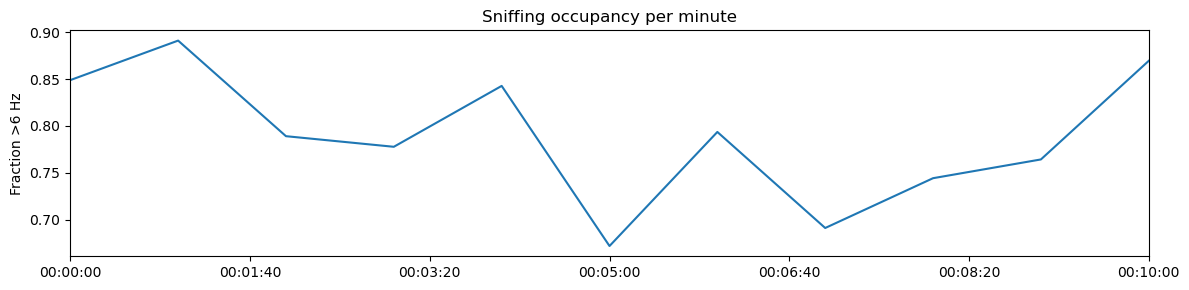

In [126]:
sniff_thresh = 6.0
sniff_occ = (rate_s > sniff_thresh).resample('60s').mean()  # fraction 0–1

print(sniff_occ.describe())
sniff_occ.plot(figsize=(12,3), lw=1.5)
plt.ylabel("Fraction >6 Hz"); plt.title("Sniffing occupancy per minute")
plt.tight_layout(); plt.show()


Dominant freq (Hz) p25/med/p75: [7.5  8.75 9.5 ]


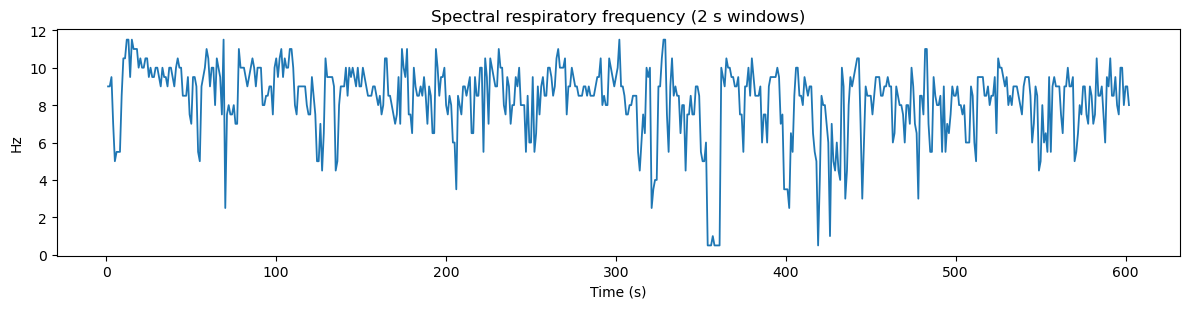

In [127]:
sig, Fs = resp_f, fs_ds  # filtered @100 Hz
nper, nover = int(Fs*2.0), int(Fs*1.0)  # 2s windows, 1s overlap
f, tt, Sxx = spectrogram(sig, fs=Fs, nperseg=nper, noverlap=nover,
                         scaling='density', mode='psd')
band = (f >= 0.5) & (f <= 15.0)
dom_freq = f[band][np.argmax(Sxx[band, :], axis=0)]

print("Dominant freq (Hz) p25/med/p75:",
      np.percentile(dom_freq, [25,50,75]).round(2))
plt.figure(figsize=(12,3.2))
plt.plot(tt, dom_freq, lw=1.3)
plt.ylabel("Hz"); plt.xlabel("Time (s)")
plt.title("Spectral respiratory frequency (2 s windows)")
plt.tight_layout(); plt.show()


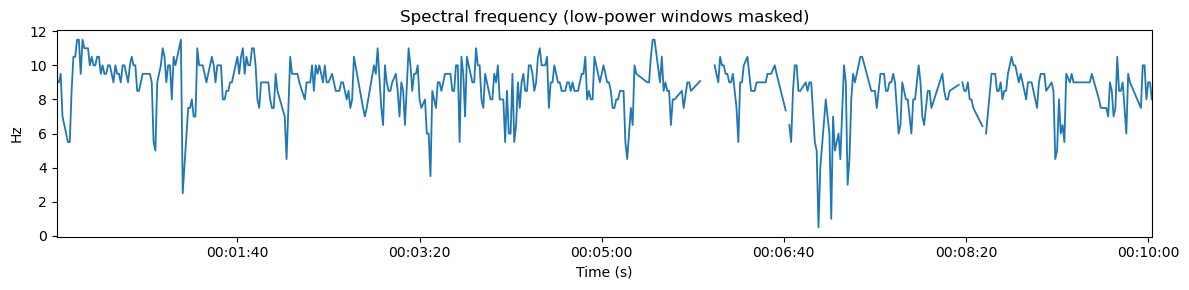

In [128]:
# reuse f, tt, Sxx from your spectrogram (Fs=100, 2 s windows, 1 s overlap)
import numpy as np
band = (f >= 0.5) & (f <= 15.0)

bandpow = Sxx[band, :].sum(axis=0)              # power in resp band
thr = np.percentile(bandpow, 20)                # drop bottom 20% (tweak)
spec_ok = pd.Series(dom_freq, index=pd.to_timedelta(tt, 's'))
mask = bandpow >= thr
spec_ok[~mask] = np.nan                         # set unreliable windows to NaN
spec_ok = spec_ok.interpolate(limit=5)          # small gaps

ax = spec_ok.plot(figsize=(12,3), lw=1.3)
ax.set_ylabel('Hz'); ax.set_xlabel('Time (s)')
ax.set_title('Spectral frequency (low-power windows masked)')
ax.figure.tight_layout()


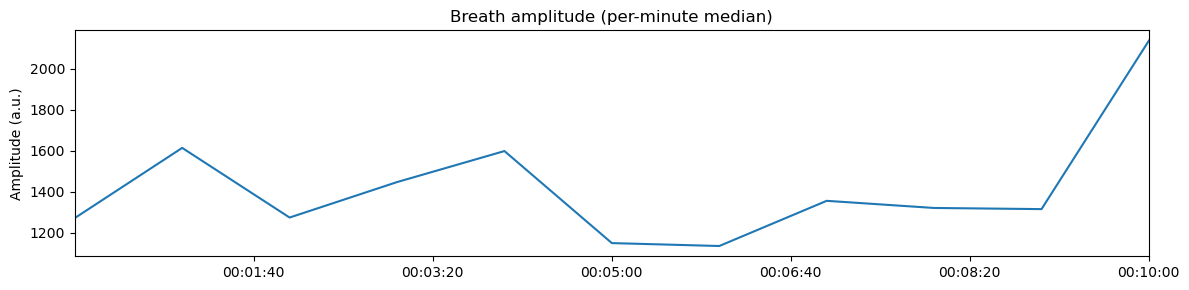

In [129]:
# simple per-breath amplitude: peak-to-trough in 0.4 s after each trough
from scipy.signal import find_peaks

sig, Fs = resp_f, fs_ds
peaks_pos, _ = find_peaks(sig, distance=int(Fs*0.09))
amp = []
t_amp = []
for ti in trough_idx2:
    cand = peaks_pos[(peaks_pos>=ti) & (peaks_pos<ti+int(Fs*0.4))]
    if cand.size:
        pk = cand[np.argmax(sig[cand])]
        amp.append(sig[pk] - sig[ti])
        t_amp.append(pk/Fs)
amp_s = pd.Series(amp, index=pd.to_timedelta(t_amp, 's'))

ax = amp_s.resample('60s').median().plot(figsize=(12,3), lw=1.5)
ax.set_ylabel('Amplitude (a.u.)')
ax.set_title('Breath amplitude (per-minute median)')
ax.figure.tight_layout()


In [130]:
# assumes:
#   amp_s  -> per-breath amplitude Series (index = time, seconds as Timedelta)
#   rate_s -> instantaneous rate Series (same indexing)

# 1) How many breaths per minute contributed to the median?
permin_count = amp_s.resample('60s').count()
print(permin_count)

# 2) Are there big outliers? Look at 10th/90th percentiles per minute
permin_q10 = amp_s.resample('60s').quantile(0.10)
permin_q90 = amp_s.resample('60s').quantile(0.90)

# 3) Robust median if you trim extreme 1% (guards against artifacts)
amp_trim = amp_s.clip(amp_s.quantile(0.01), amp_s.quantile(0.99))
permin_amp_trim = amp_trim.resample('60s').median()


0 days 00:00:00.120000    425
0 days 00:01:00.120000    423
0 days 00:02:00.120000    423
0 days 00:03:00.120000    397
0 days 00:04:00.120000    387
0 days 00:05:00.120000    372
0 days 00:06:00.120000    374
0 days 00:07:00.120000    404
0 days 00:08:00.120000    365
0 days 00:09:00.120000    280
0 days 00:10:00.120000     11
Freq: 60s, dtype: int64


In [132]:
# Make sure both are Timedelta-indexed, sorted, and numeric
spec_s = spec_s.astype(float).sort_index()   # spectral freq @ times tt
peak_s = peak_s.astype(float).sort_index()   # peak-based rate @ times t_rate2

# Nearest match within 0.5 s tolerance
df = pd.merge_asof(
    left=peak_s.to_frame('peak'),
    right=spec_s.to_frame('spec'),
    left_index=True,
    right_index=True,
    direction='nearest',
    tolerance=pd.Timedelta('500ms')
).dropna()

print("Aligned pairs:", len(df))
if len(df) >= 3 and df['peak'].std() > 0 and df['spec'].std() > 0:
    print("Pearson r:", df['peak'].corr(df['spec'], method='pearson'))
    print("Spearman ρ:", df['peak'].corr(df['spec'], method='spearman'))
else:
    print("Not enough overlapping, non-constant data after nearest alignment.")


Aligned pairs: 3613
Pearson r: 0.36782823713323426
Spearman ρ: 0.38456822334577667


Text(0.5, 1.0, 'Rate agreement (aligned pairs)')

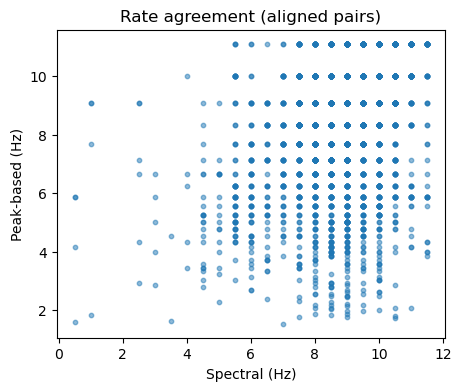

In [133]:
ax = df.plot(kind='scatter', x='spec', y='peak', s=10, alpha=0.5, figsize=(5,4))
ax.set_xlabel("Spectral (Hz)"); ax.set_ylabel("Peak-based (Hz)")
ax.set_title("Rate agreement (aligned pairs)")


In [134]:
# inputs you already have:
# dom_freq (Hz) at times tt (s) from spectrogram (2 s windows, 1 s hop)
# rate_hz2 (Hz) at times t_rate2 (s) from peaks/troughs (strict settings)

import numpy as np, pandas as pd

rate_s = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2, unit='s'))
tt_td  = pd.to_timedelta(tt, unit='s')

win = 2.0  # seconds (match nperseg/Fs)
half = win/2

peak_on_spec = []
for tc in tt:
    t0 = pd.to_timedelta(tc - half, unit='s')
    t1 = pd.to_timedelta(tc + half, unit='s')
    vals = rate_s.loc[t0:t1]
    peak_on_spec.append(np.nan if len(vals)<2 else np.median(vals))  # need ≥2 breaths

peak_on_spec = pd.Series(peak_on_spec, index=tt_td, name="peak2s")
spec_series  = pd.Series(dom_freq, index=tt_td, name="spec2s")


In [135]:
# Prereqs already in your notebook: resp_f (filtered @100 Hz), fs_ds, rate_hz2, t_rate2
import numpy as np, pandas as pd
from scipy.signal import spectrogram

sig, Fs = resp_f, fs_ds  # filtered signal @100 Hz

# --- Spectral frequency on 2 s windows (1 s overlap) ---
nper = int(Fs*2); nover = int(Fs*1)
f, tt, Sxx = spectrogram(sig, fs=Fs, nperseg=nper, noverlap=nover,
                         scaling='density', mode='psd')
band = (f >= 0.5) & (f <= 15.0)
dom_freq = f[band][np.argmax(Sxx[band, :], axis=0)]
bandpow  = Sxx[band, :].sum(axis=0)

spec_series = pd.Series(dom_freq, index=pd.to_timedelta(tt, unit='s'), name='spec2s')
thr = np.percentile(bandpow, 20)                   # drop low-power windows (tweak if needed)
spec_masked = spec_series.mask(bandpow < thr)      # <-- defines spec_masked

# --- Aggregate peak-based rate into the same 2 s windows (median in [tc-1, tc+1]) ---
rate_s = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2, unit='s'))
win = 2.0; half = win/2
tt_td = pd.to_timedelta(tt, unit='s')

vals_list = []
for tc in tt:
    t0 = pd.to_timedelta(tc - half, unit='s')
    t1 = pd.to_timedelta(tc + half, unit='s')
    vals = rate_s.loc[t0:t1]
    vals_list.append(np.nan if len(vals) < 2 else float(vals.median()))

peak_on_spec = pd.Series(vals_list, index=tt_td, name="peak2s")

# --- Align, drop NaNs, correlate ---
df = pd.concat([peak_on_spec, spec_masked], axis=1).dropna()
print("Windows kept:", len(df))
if len(df) >= 10 and df.std().min() > 0:
    print("Pearson r:", df.peak2s.corr(df.spec2s))
    print("Spearman ρ:", df.peak2s.corr(df.spec2s, method='spearman'))
else:
    print("Not enough variance/overlap after masking.")


Windows kept: 481
Pearson r: 0.7544740418575657
Spearman ρ: 0.7335254335552932


In [137]:
# --- FIX: per-minute summaries on TimedeltaIndex (no 'origin' needed) ---

import pandas as pd

def zero_anchor(s: pd.Series) -> pd.Series:
    """Shift a TimedeltaIndex Series so it starts at 0 seconds."""
    if len(s.index) == 0:
        return s
    s2 = s.copy()
    s2.index = s2.index - s2.index.min()
    return s2

# Use zero-anchored series for resampling
rate0 = zero_anchor(rate_s)   # rate_s: instantaneous rate (Hz) indexed by Timedelta
amp0  = zero_anchor(amp_s)    # amp_s : per-breath amplitude (a.u.) indexed by Timedelta

# Per-minute summaries
permin_rate = rate0.resample('60s').median()
sniff_occ   = (rate0 > 6.0).resample('60s').mean()

permin_amp   = amp0.resample('60s').median()
permin_count = amp0.resample('60s').count()

# Optional: drop thin/partial minutes for cleaner plots
MIN_COUNT = 200
permin_rate_clean = permin_rate.where(permin_count >= MIN_COUNT)
permin_amp_clean  = permin_amp.where(permin_count >= MIN_COUNT)


In [92]:
import os, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# small helpers
def robust_std(x):
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

def zero_anchor(s: pd.Series) -> pd.Series:
    """Shift a TimedeltaIndex Series to start at exactly 0 seconds (avoids pandas resample quirks)."""
    if len(s.index) == 0:
        return s
    s2 = s.copy()
    s2.index = s2.index - s2.index.min()
    return s2


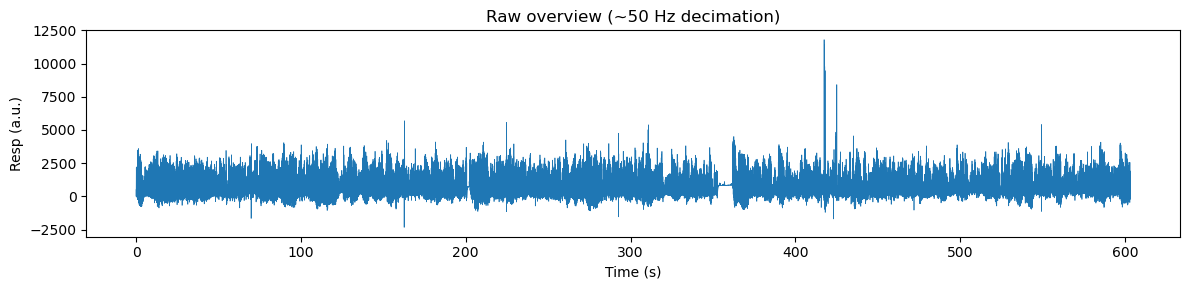

fs: 20000.0 → 100.0 Hz | len: 12065446 → 60328


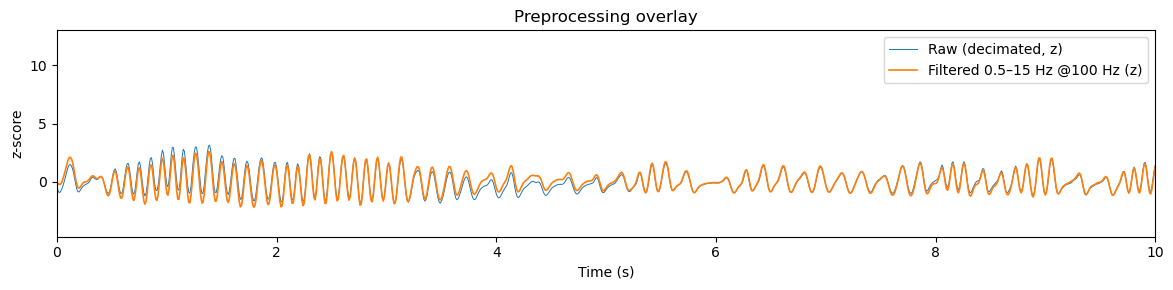

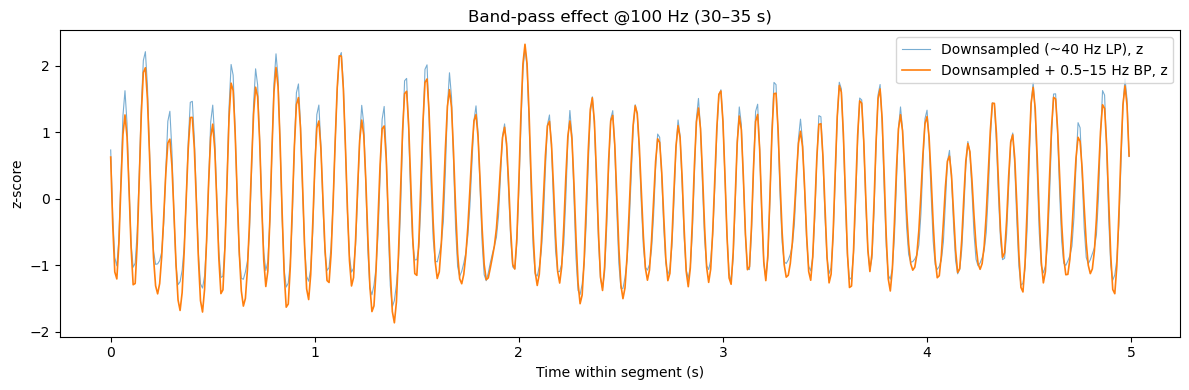

PSD dominant freq: 9.80 Hz | power 6–12 Hz: 77.3% | 1–4 Hz: 8.6%


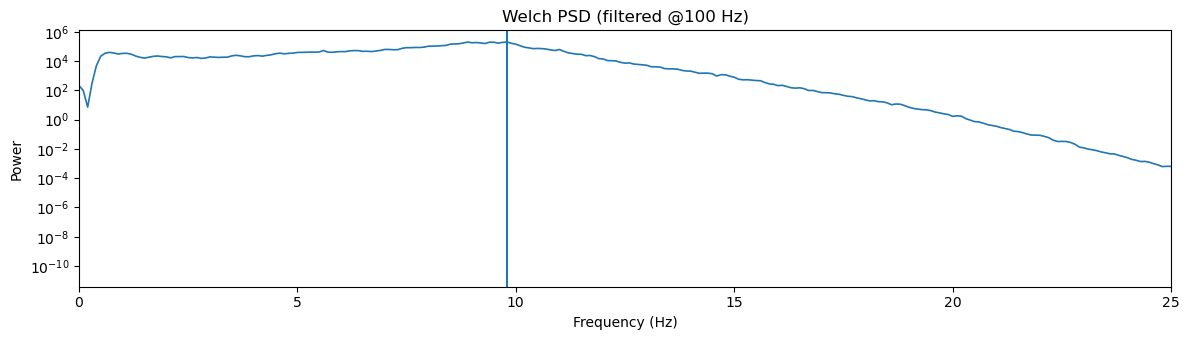

Inhale peaks: 4259 | breaths kept: 4173/4258 | median rate: 9.09 Hz


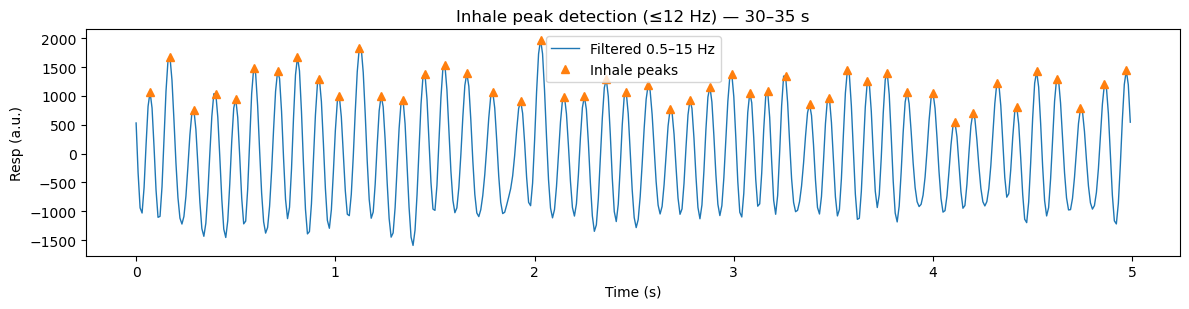

Peak vs spectral (10 s median) Pearson r: 0.800


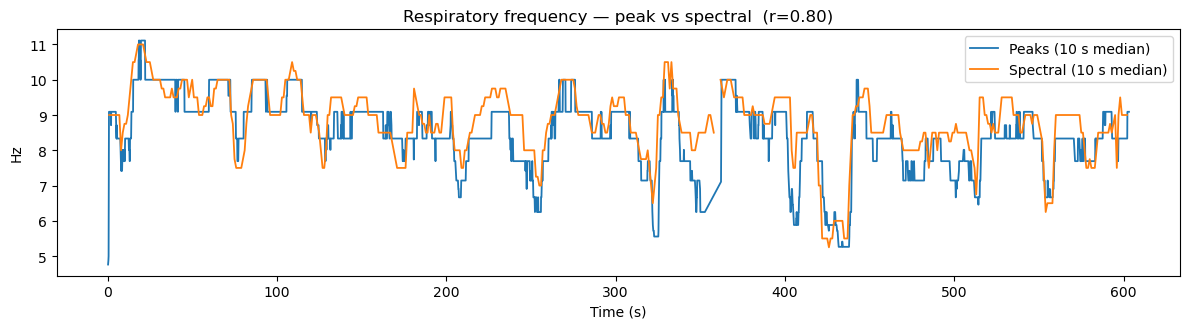

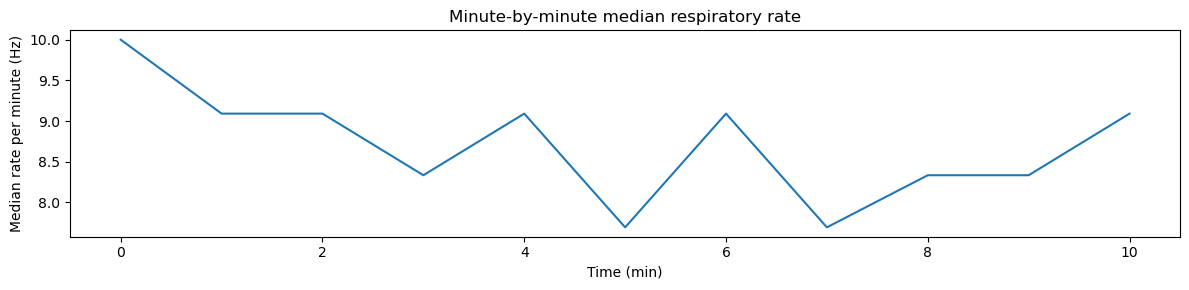

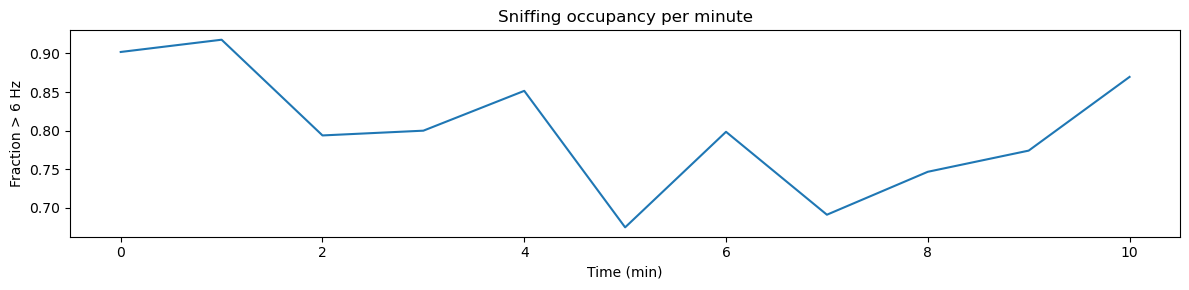

Fraction of 1-s bins >10 Hz: 0.7%
Per-minute ventilation proxy (median):
count       11.00
mean     20483.00
std       2259.67
min      17199.59
25%      18686.89
50%      21142.46
75%      21586.70
max      24074.17
dtype: float64


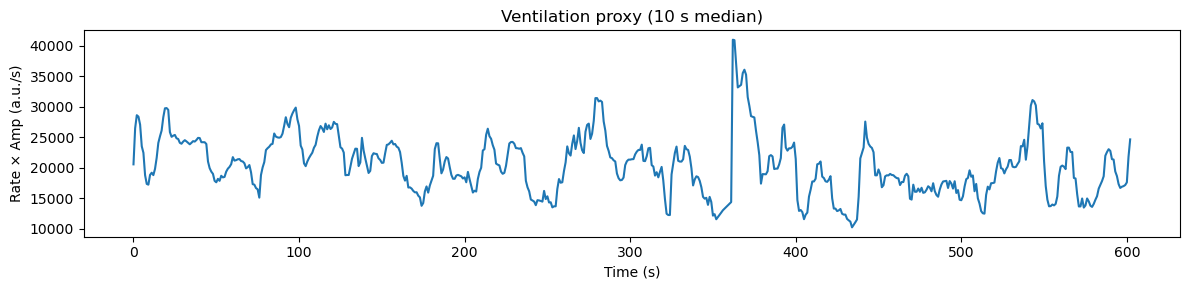

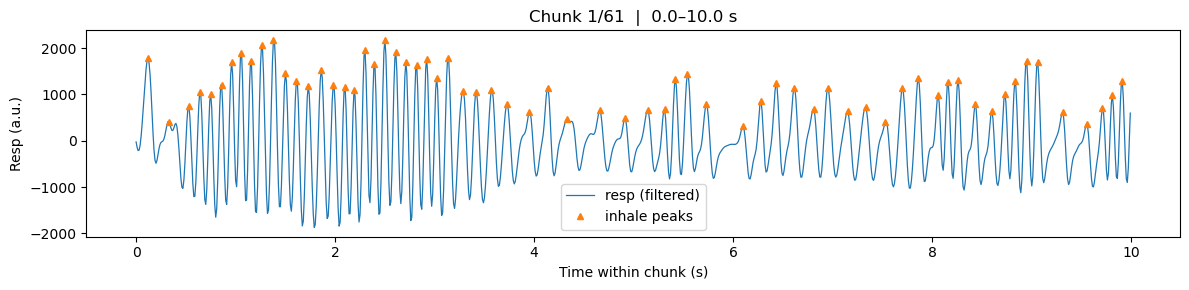

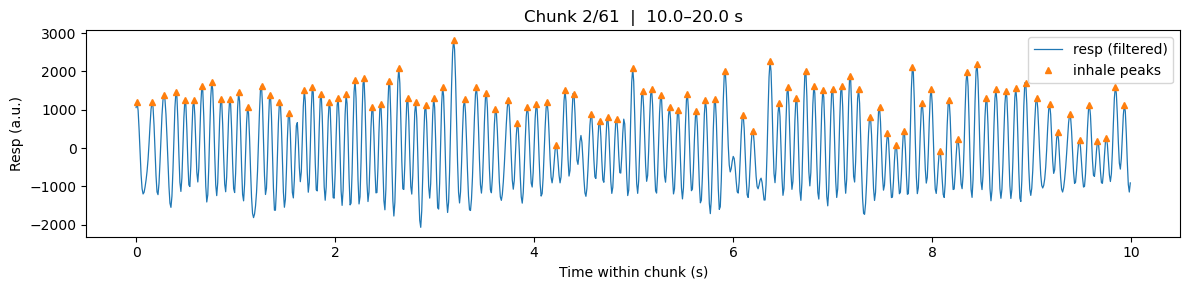

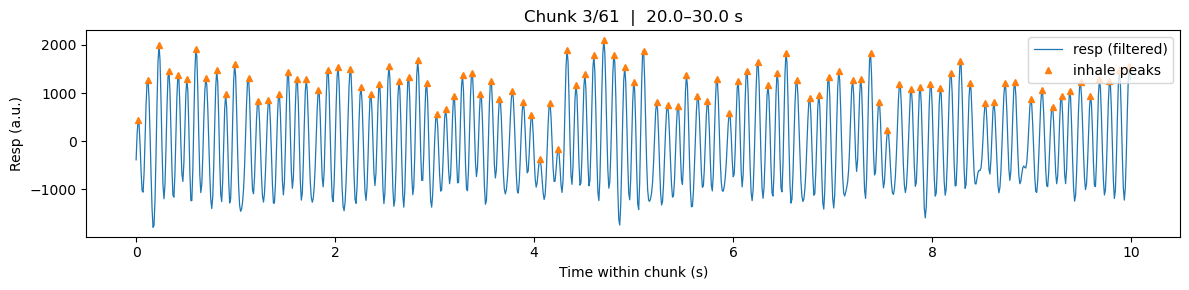

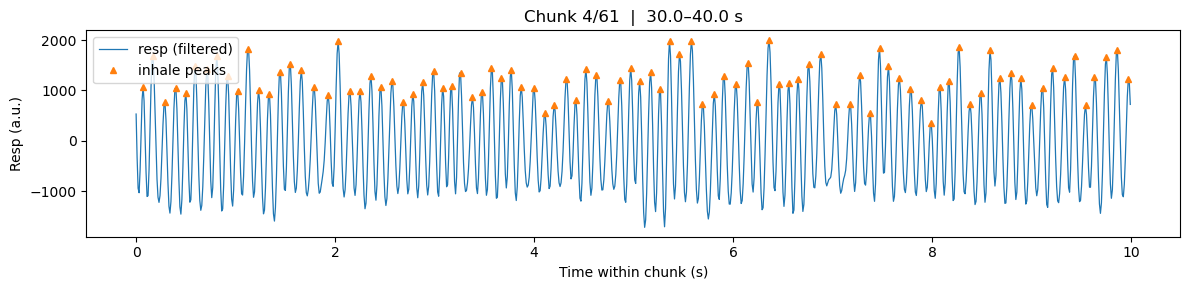

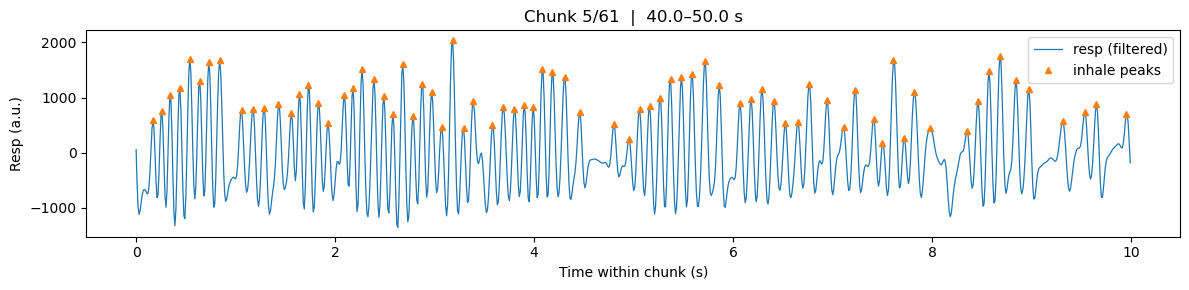

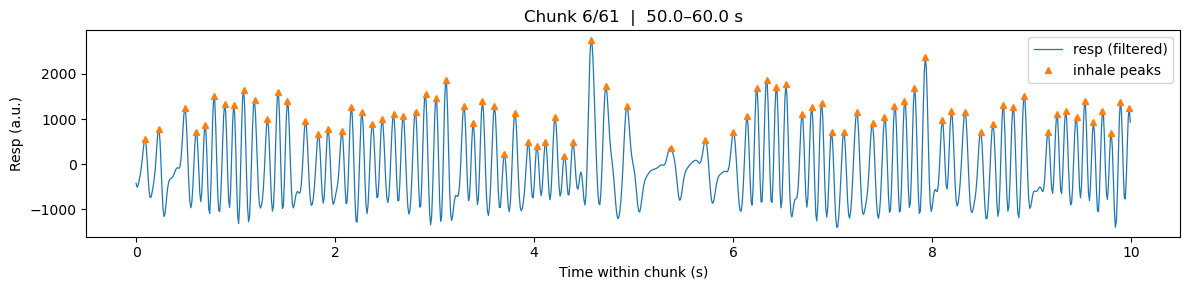

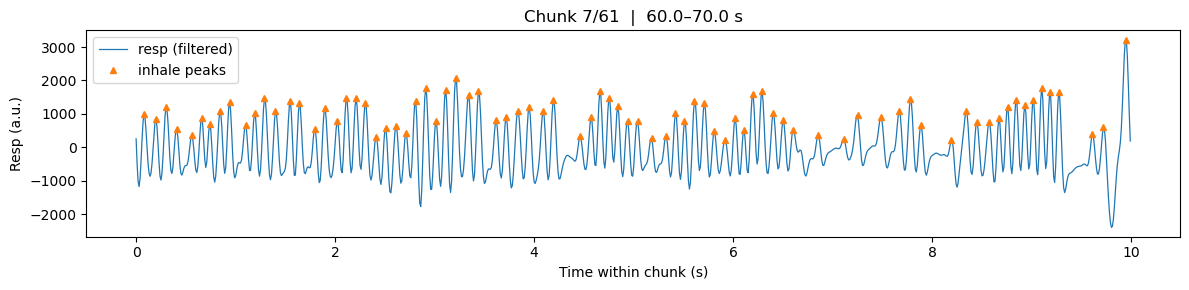

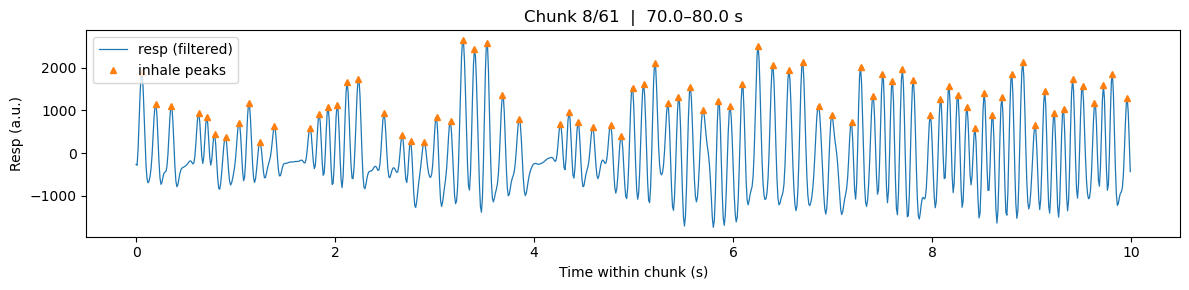

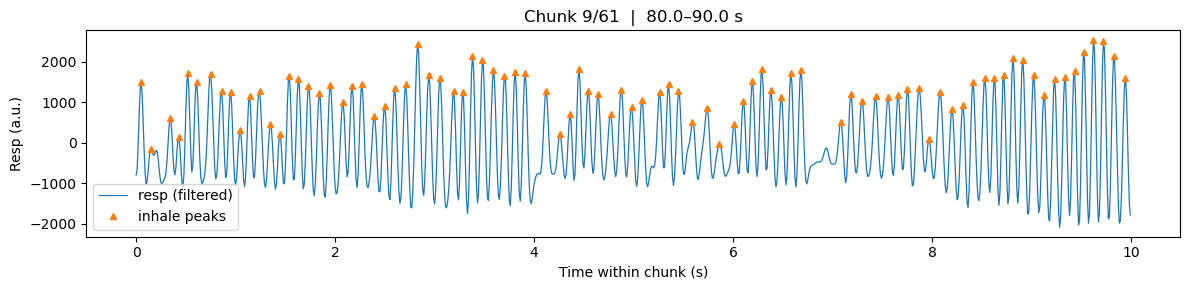

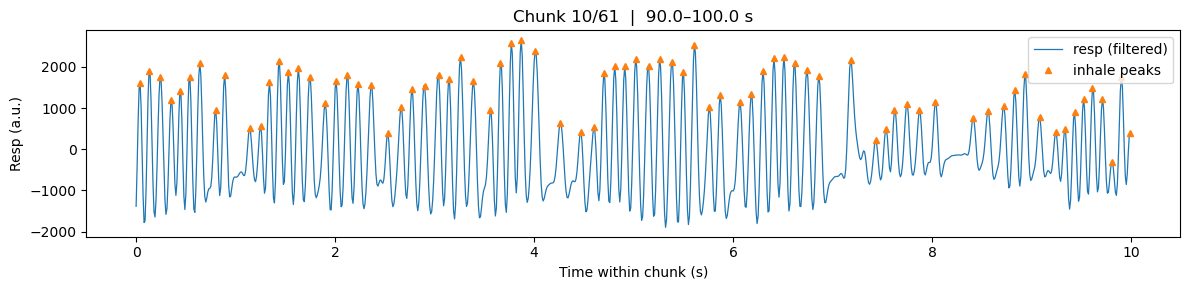

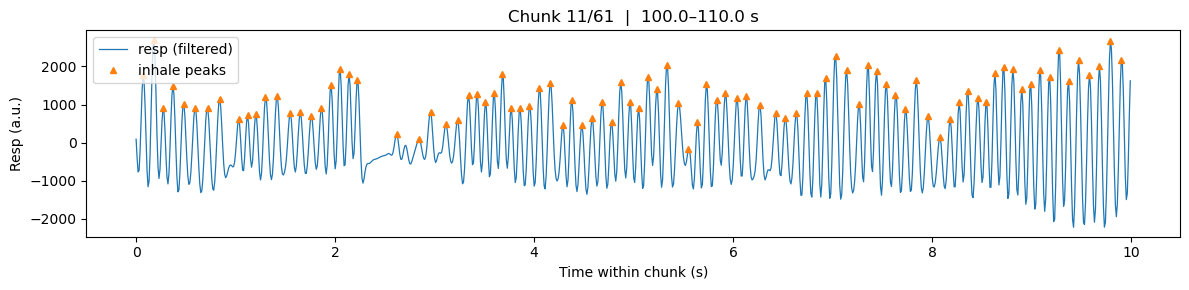

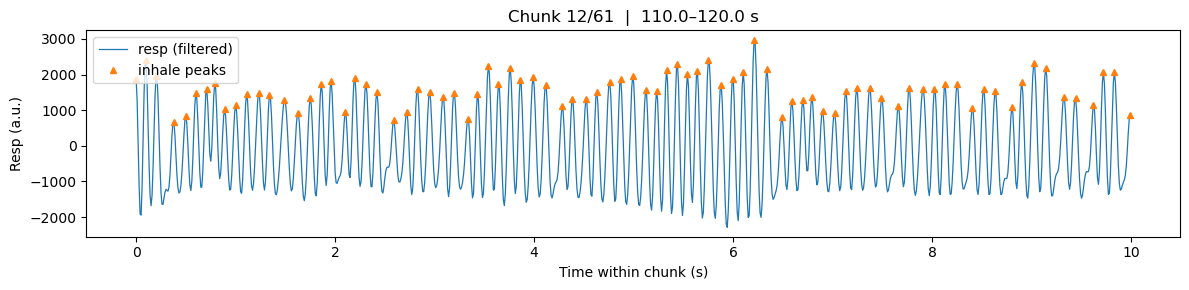

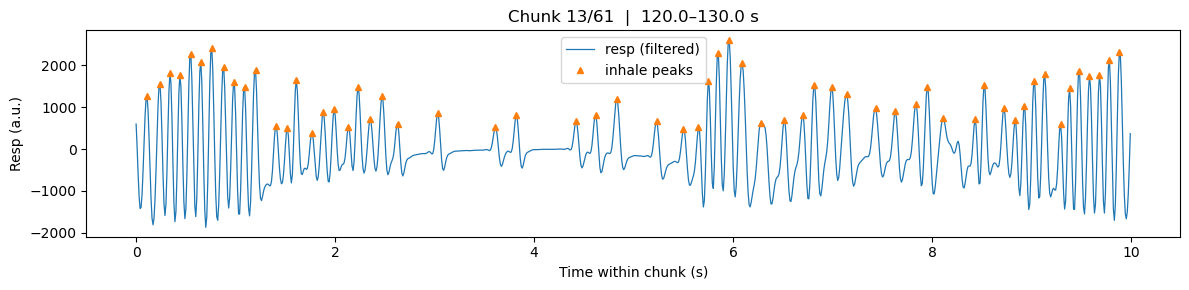

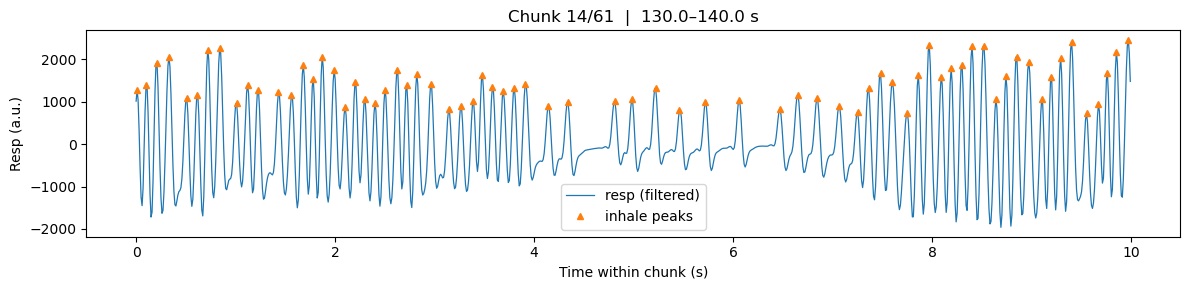

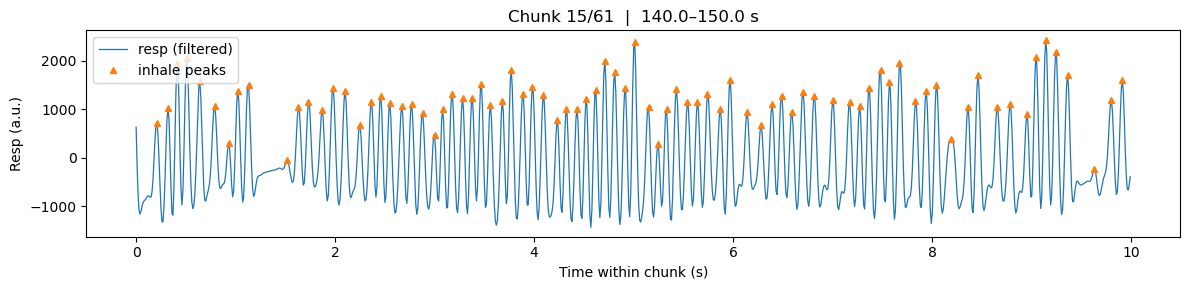

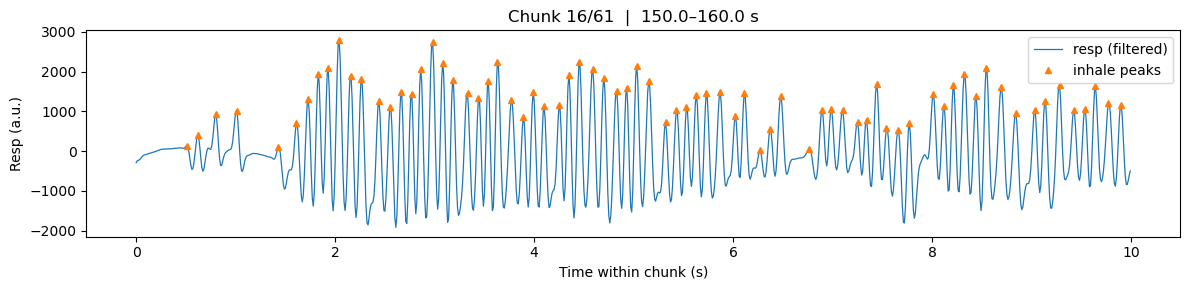

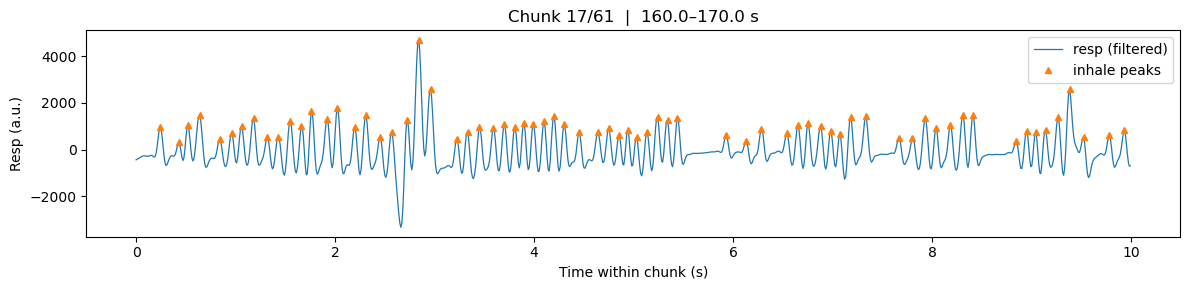

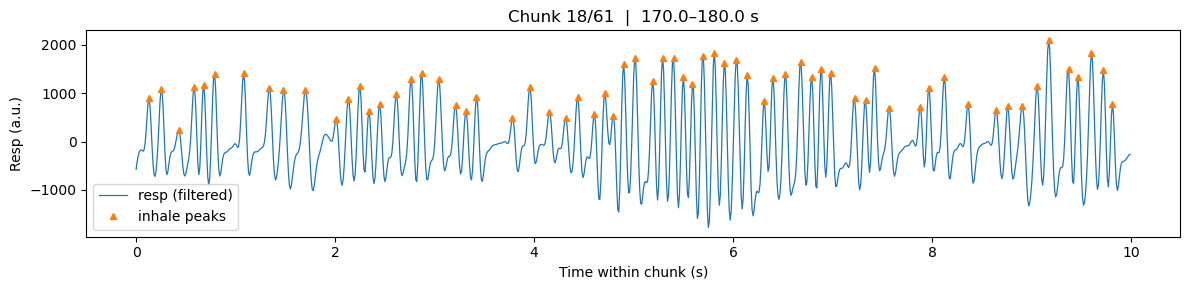

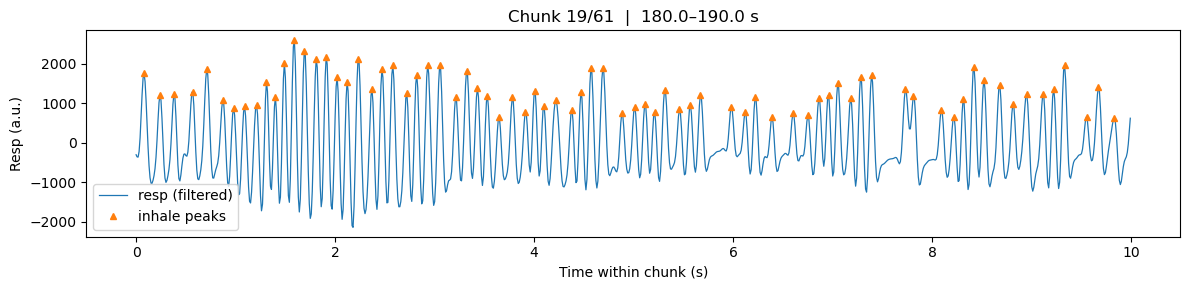

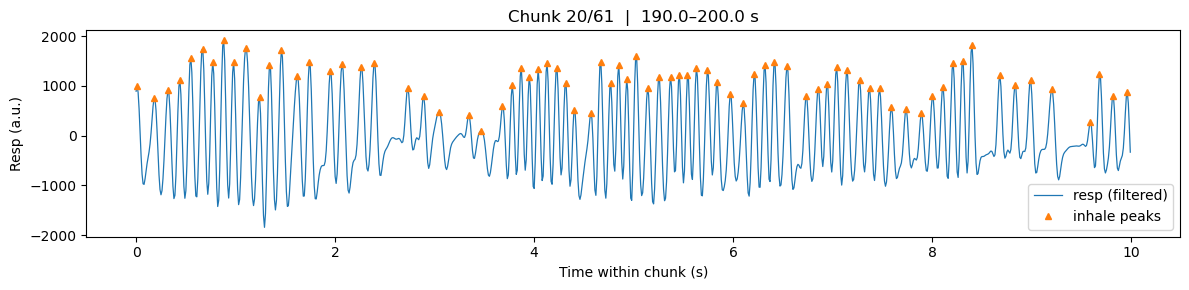

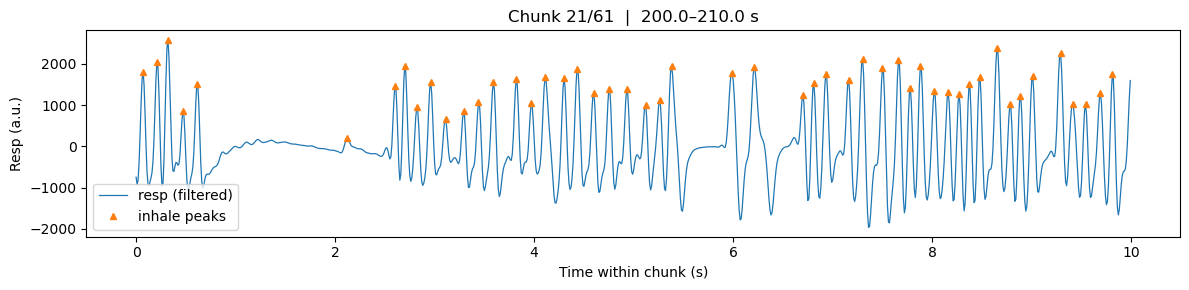

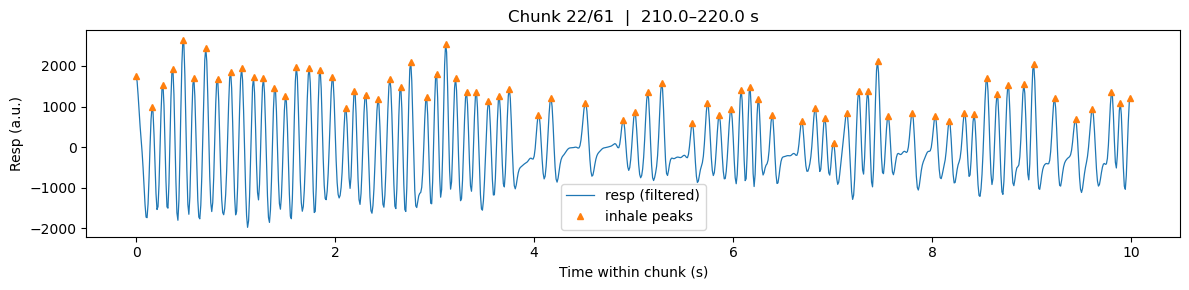

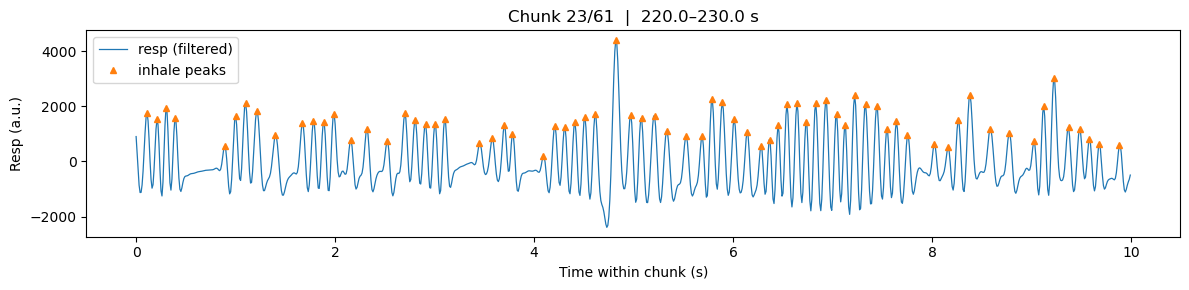

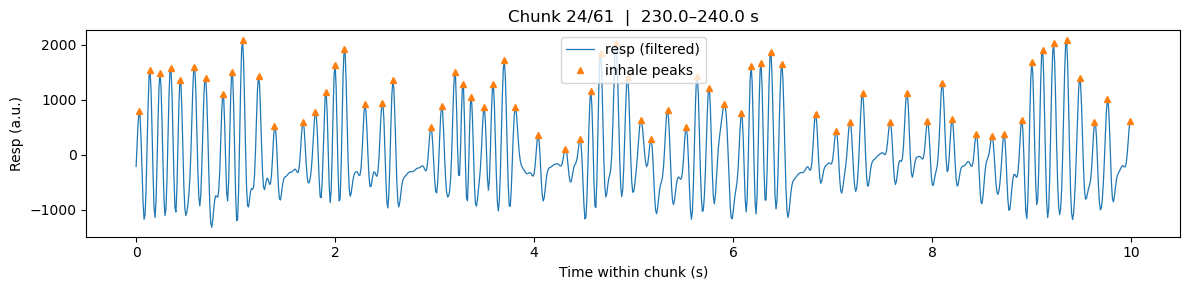

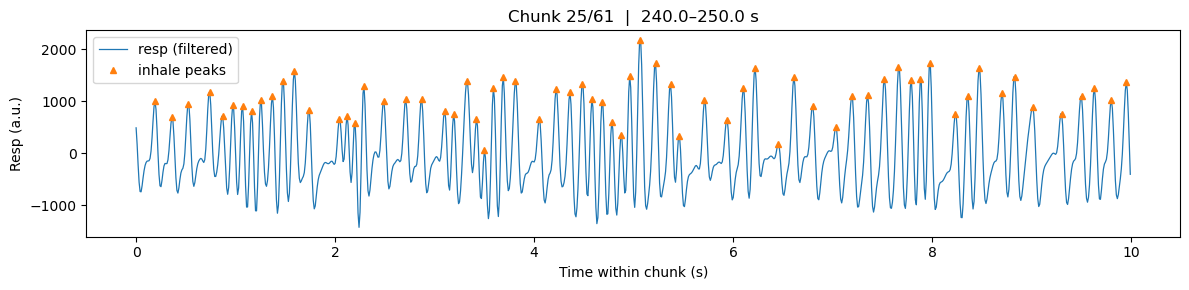

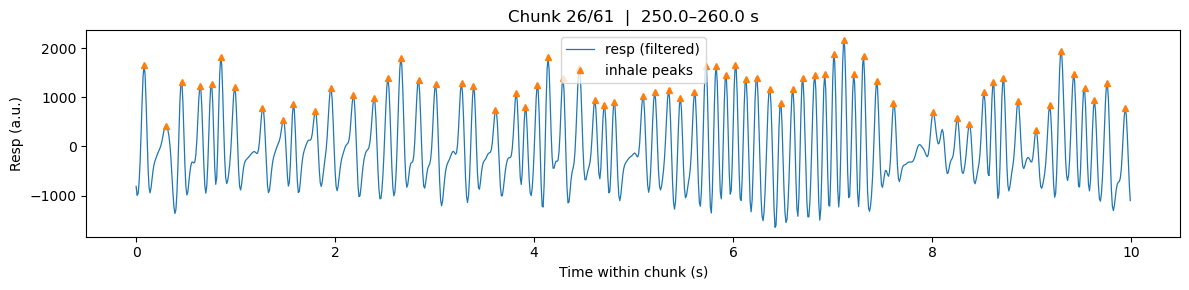

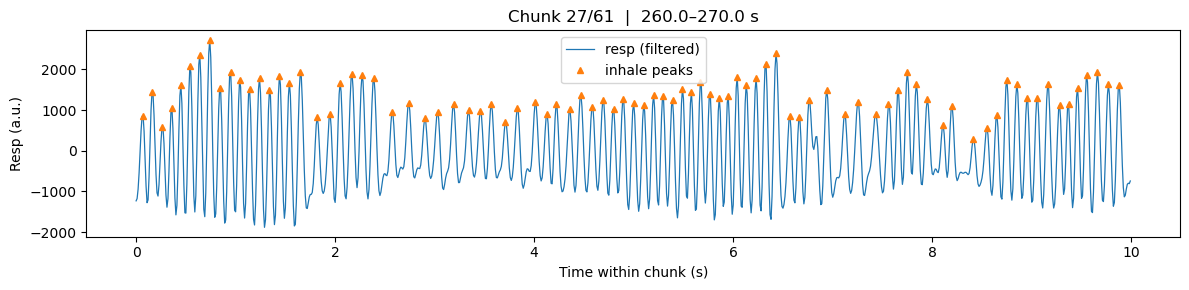

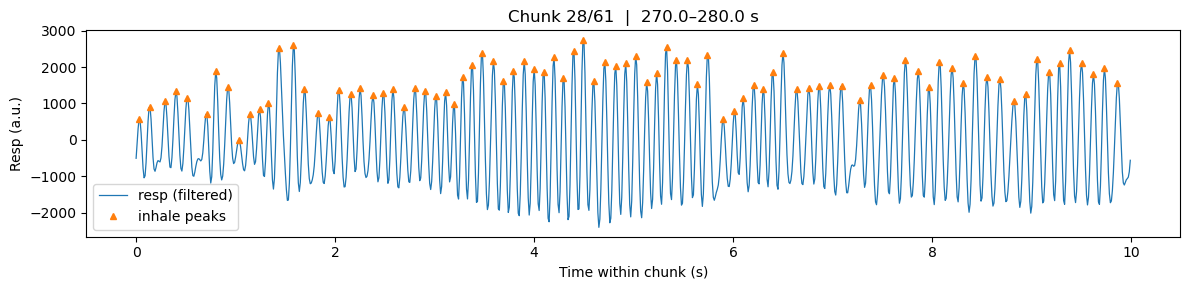

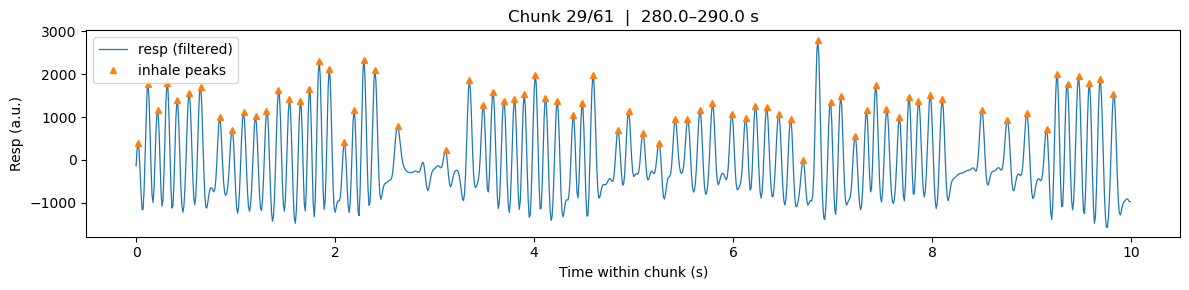

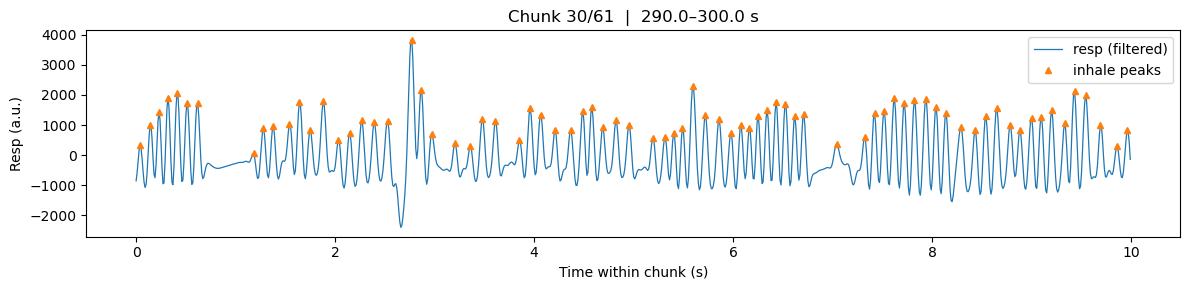

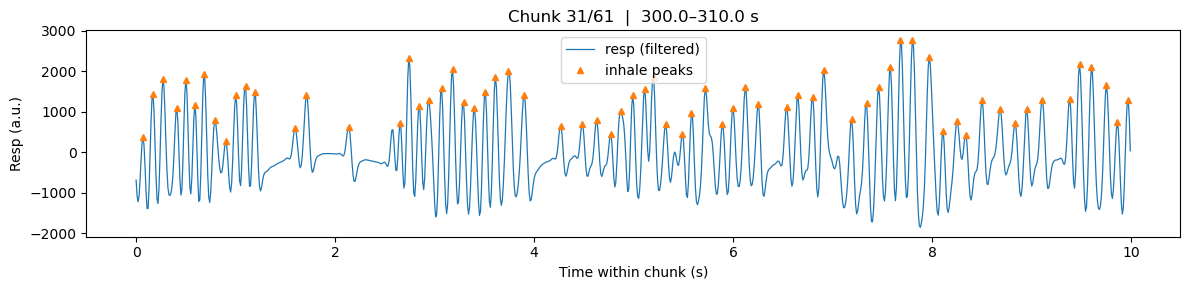

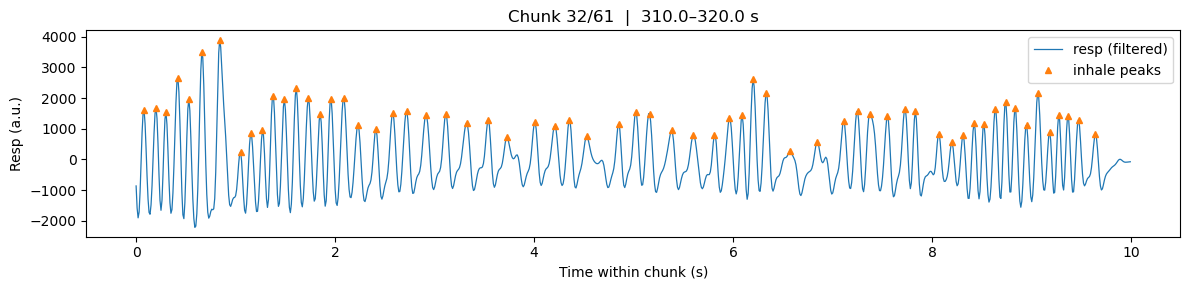

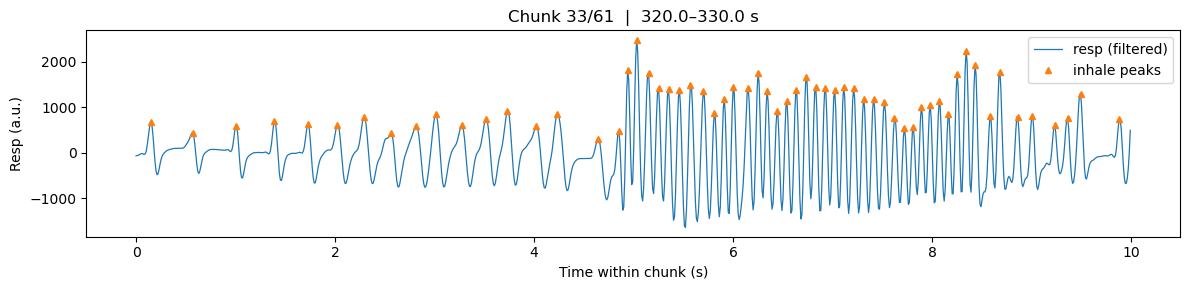

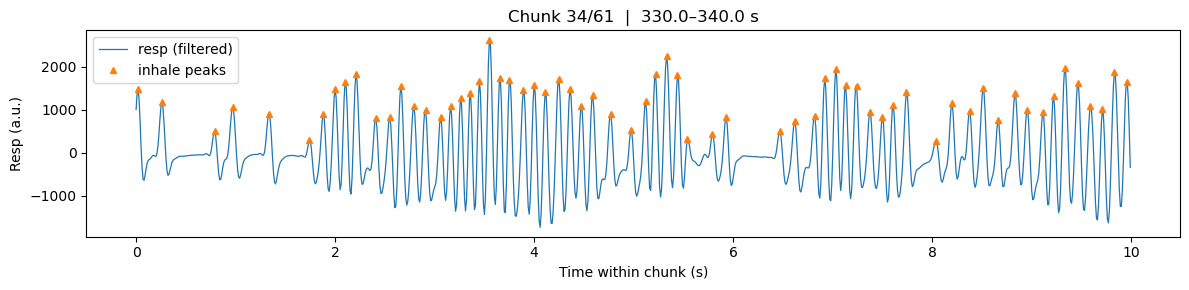

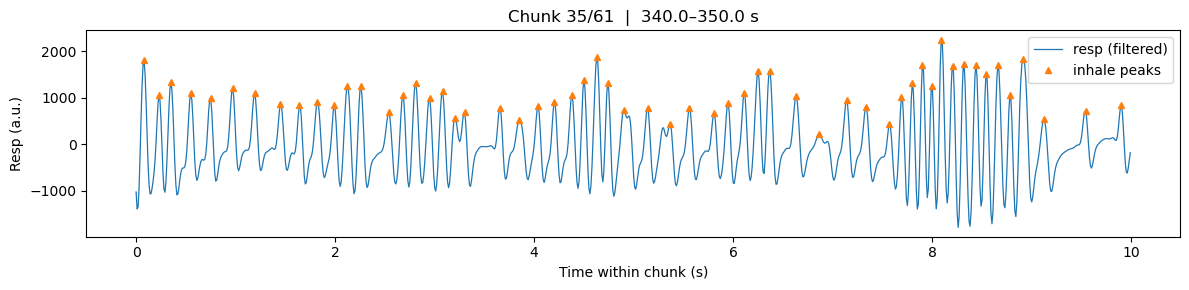

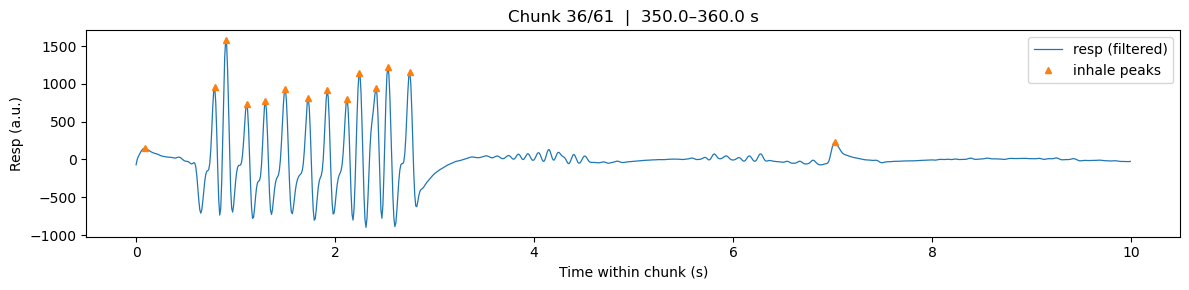

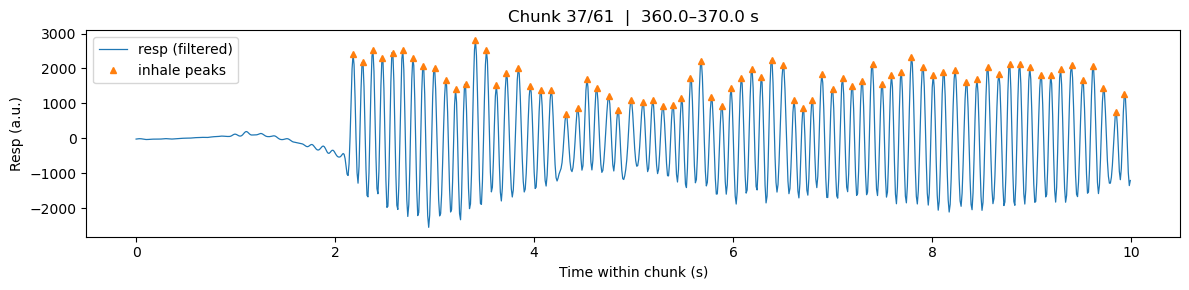

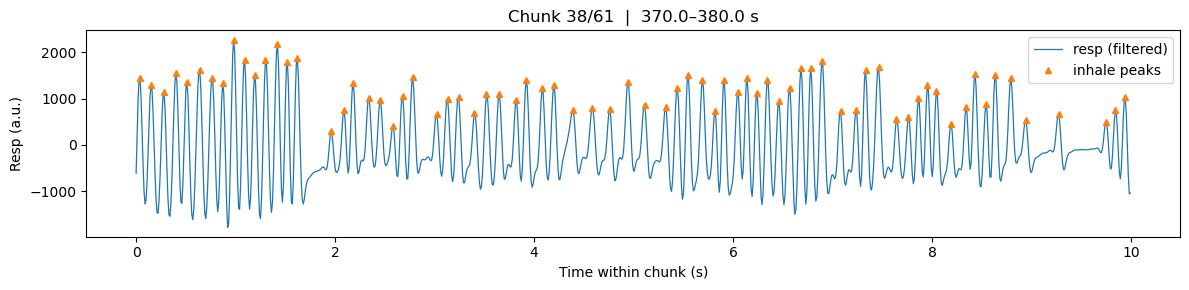

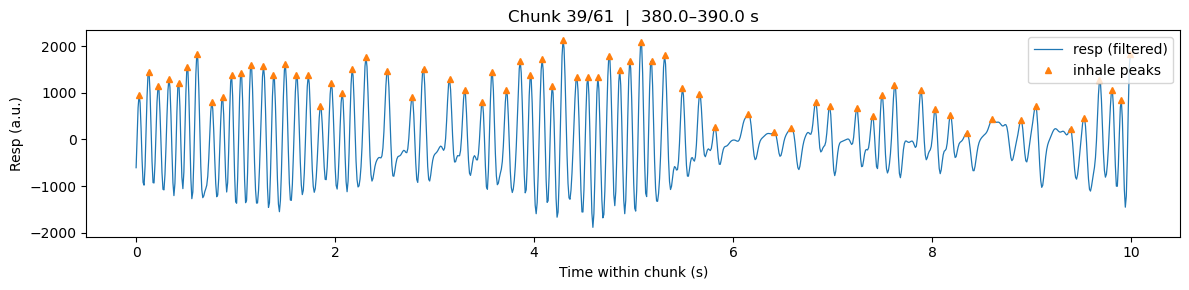

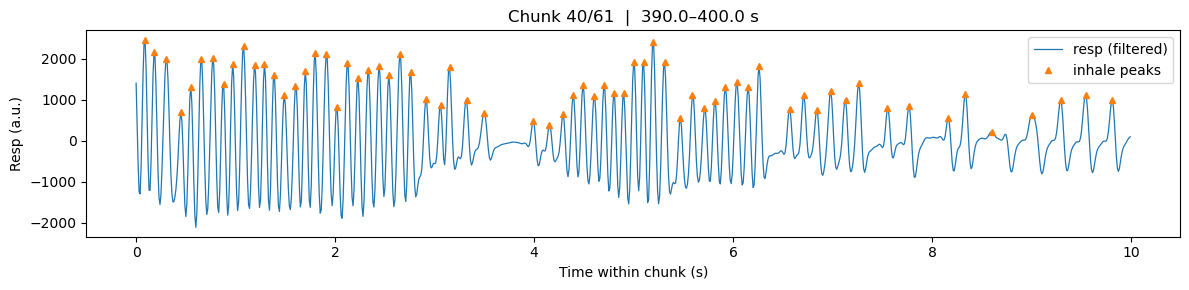

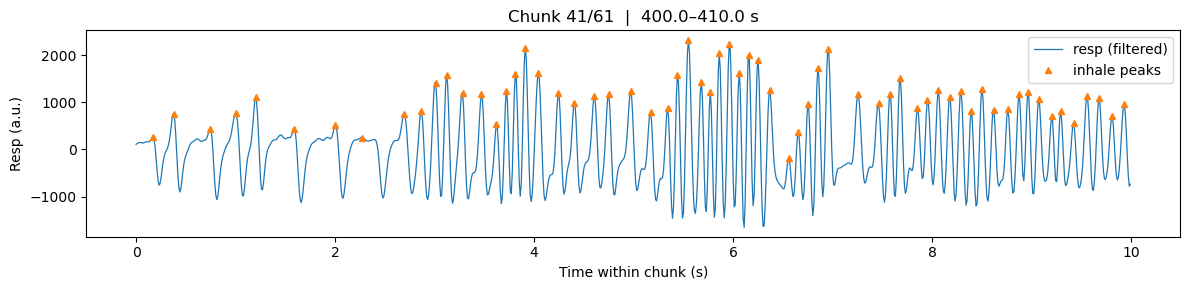

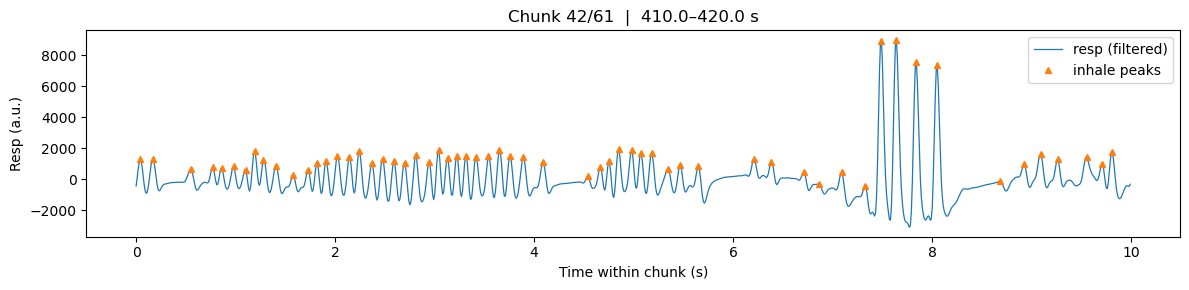

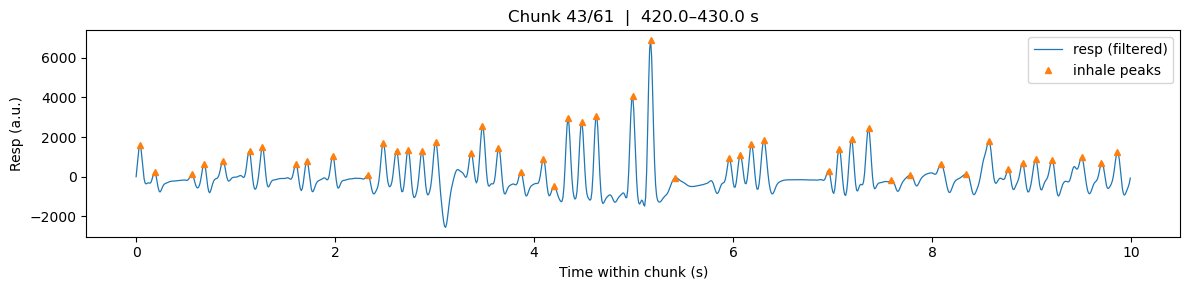

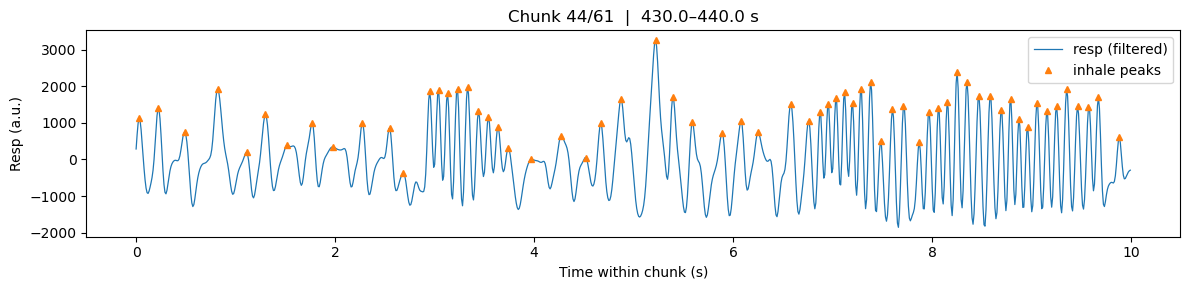

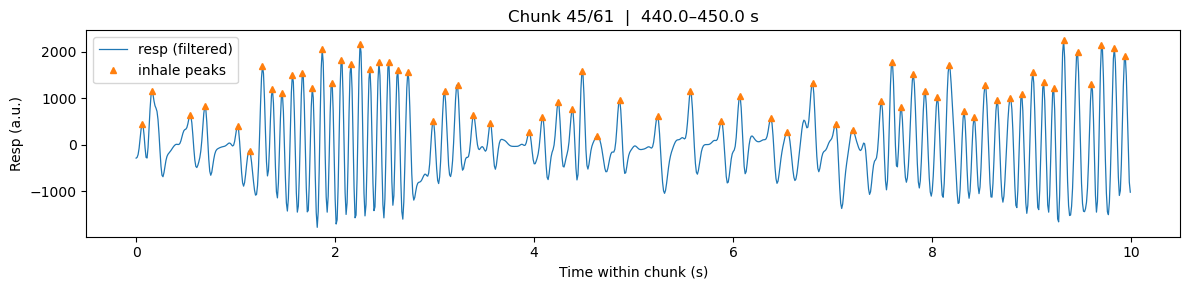

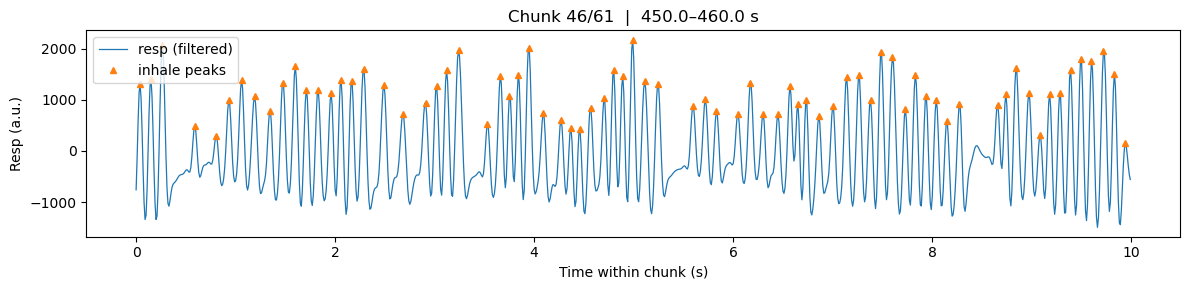

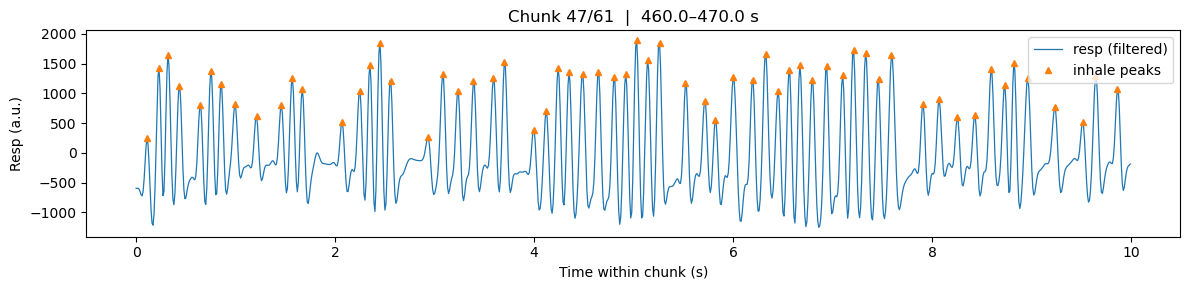

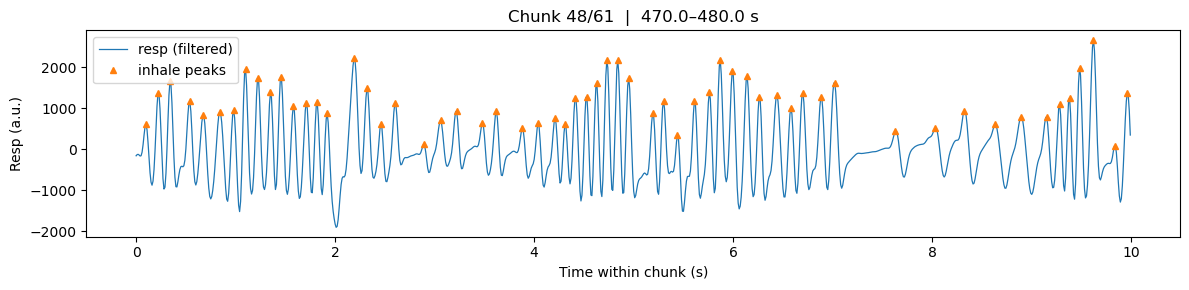

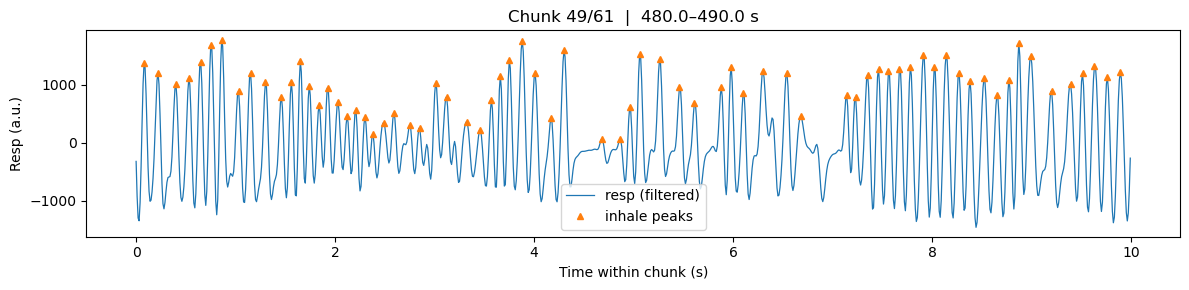

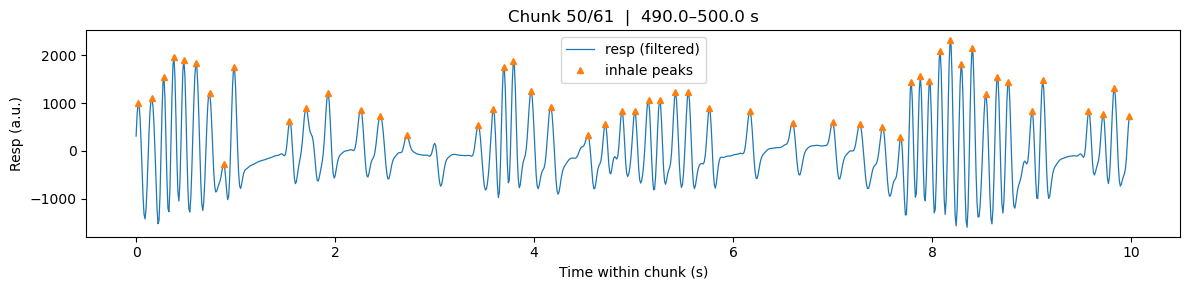

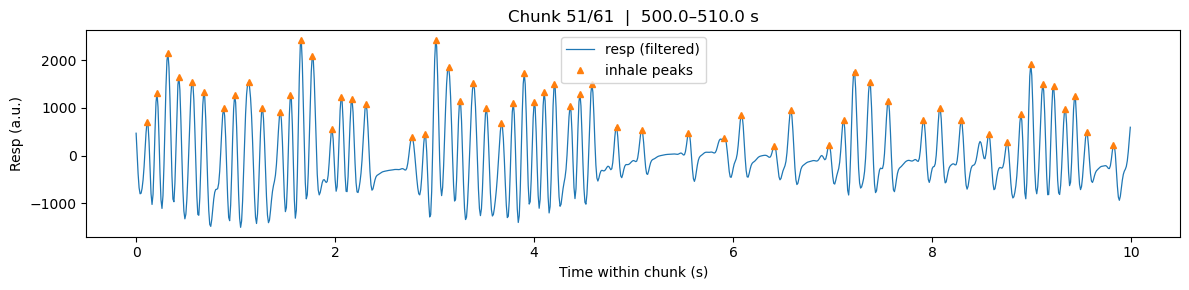

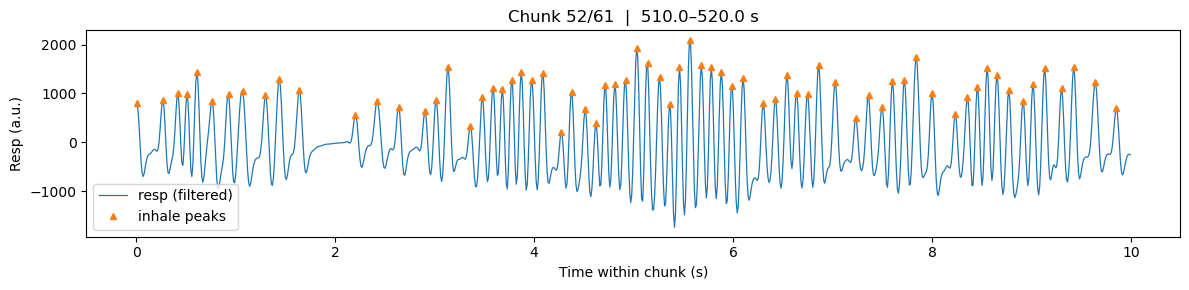

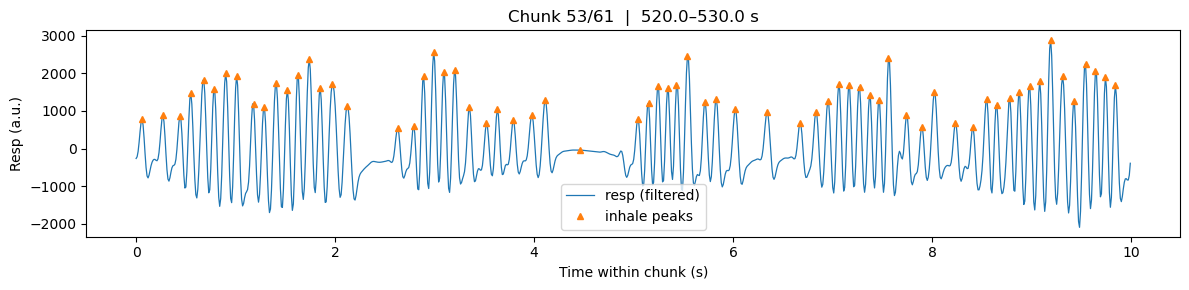

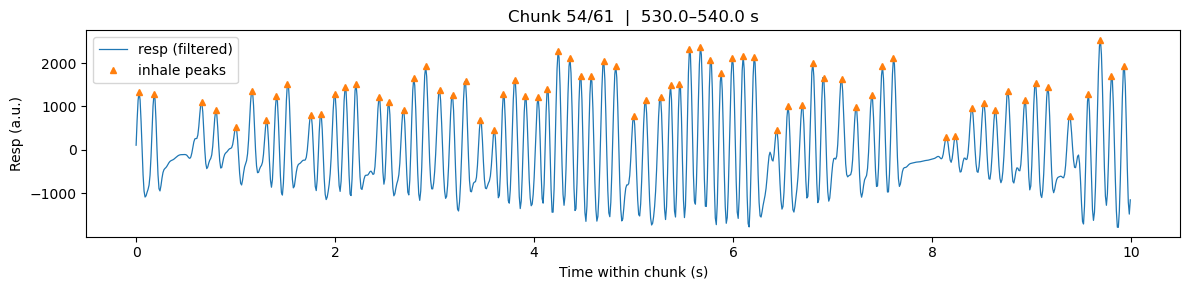

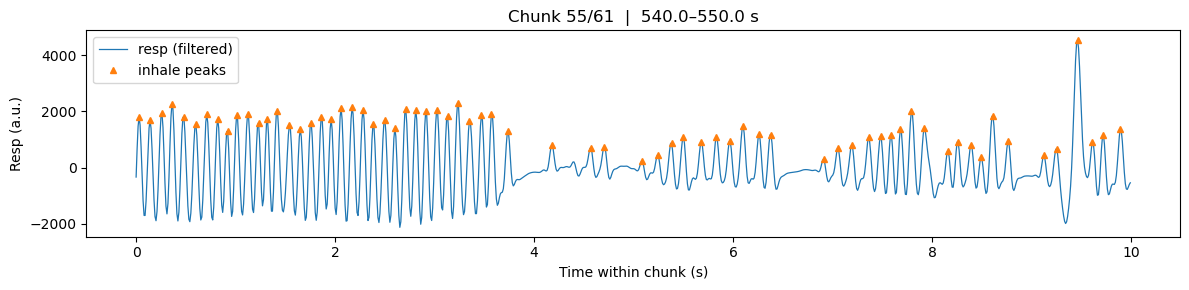

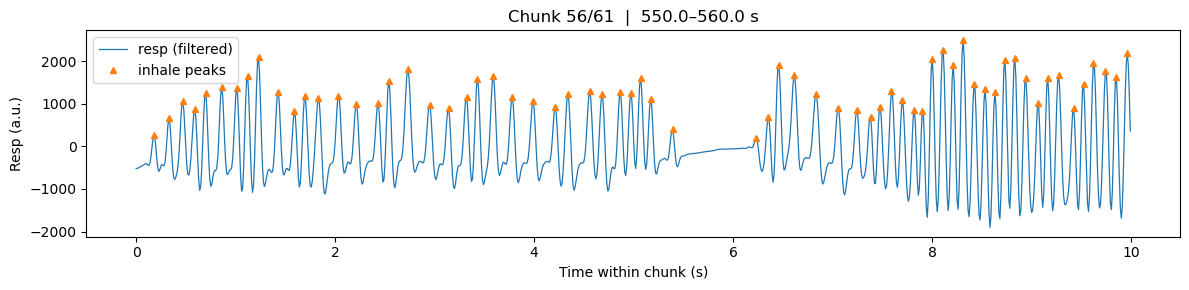

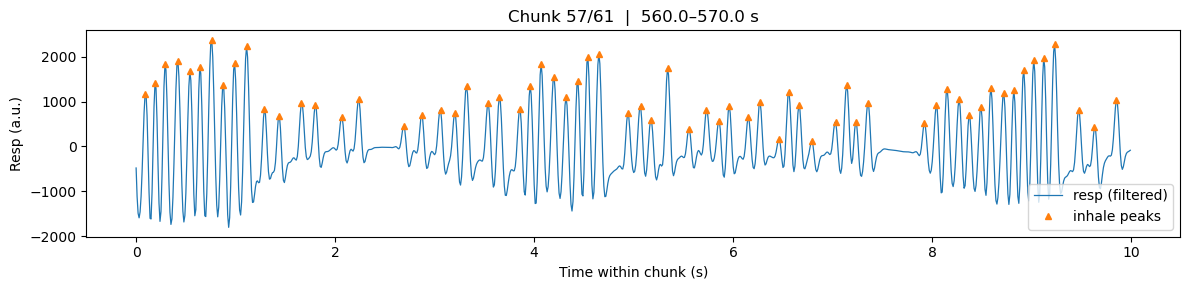

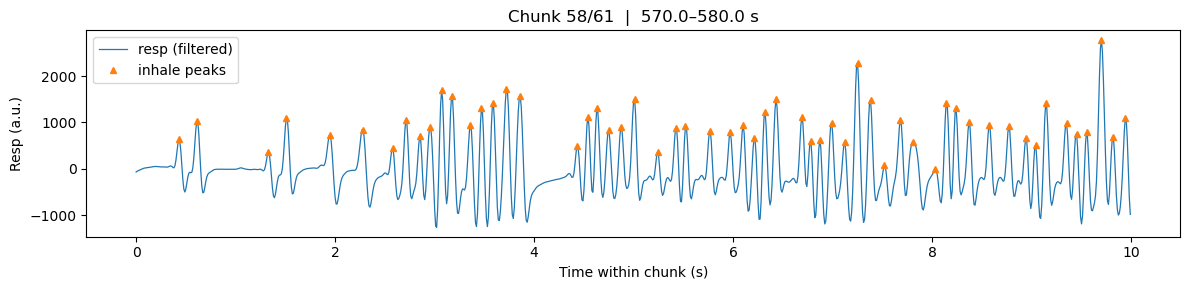

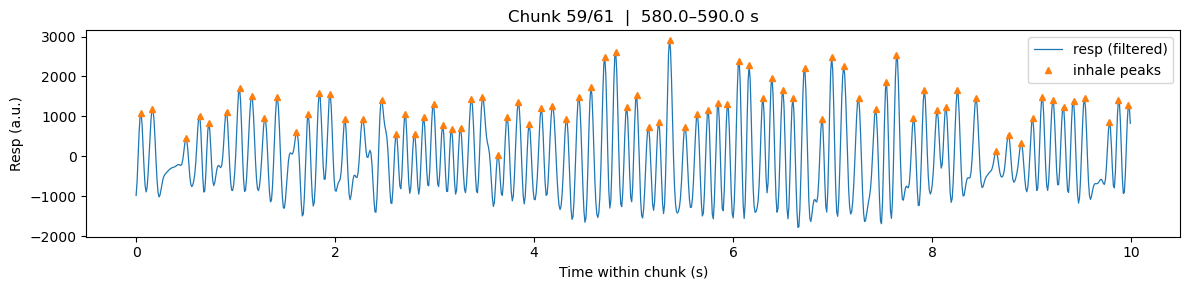

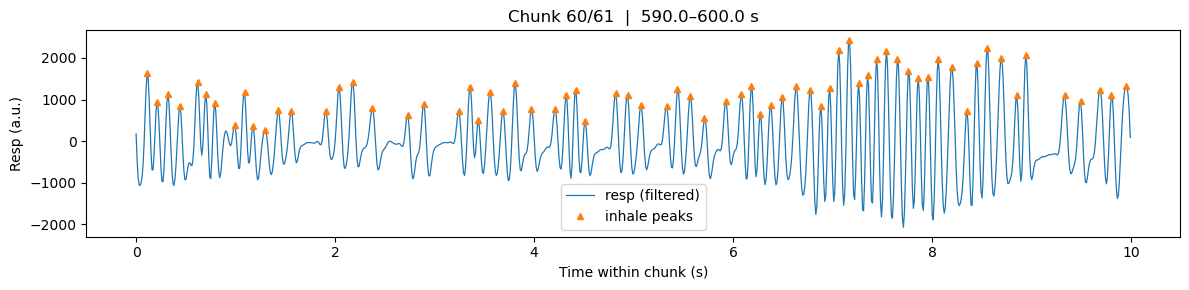

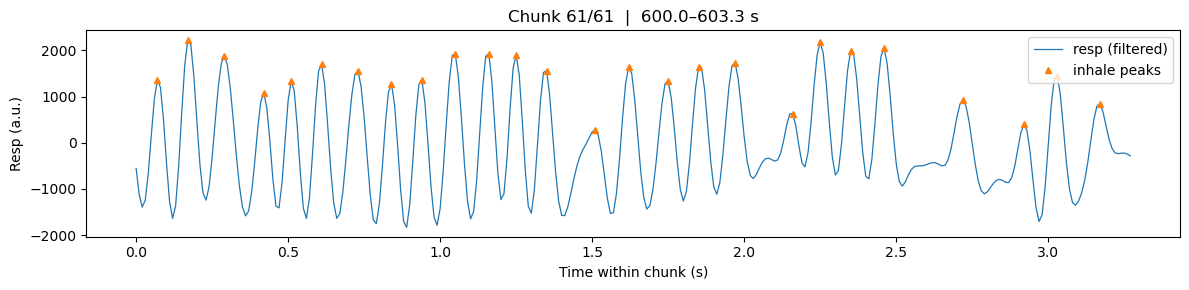

In [145]:
# =============================== Respiratory Analysis Cheat Sheet ===============================
# Assumes: resp (raw intranasal pressure, numpy array), fs (float, Hz) are already loaded.
# Outputs: cleaned 100 Hz signal, peaks, rate, PSD, QC plots (saved in figs/).
# -----------------------------------------------------------------------------------------------

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, resample_poly, welch, find_peaks, spectrogram

FIGDIR = Path("figs"); FIGDIR.mkdir(exist_ok=True)
def zscore(x): x=np.asarray(x,float); return (x-x.mean())/(x.std()+1e-12)
def robust_std(x): med=np.median(x); return 1.4826*np.median(np.abs(x-med))

# --- STEP 1: RAW OVERVIEW (visual-only decimation) ---------------------------------------------
# Quick look at the whole raw trace (NOT for analysis).
step = max(1, int(fs//50))                      # ~50 Hz view
vis  = resp[::step]; t_vis = np.arange(len(vis))*(step/fs)
plt.figure(figsize=(12,3)); plt.plot(t_vis, vis, lw=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Resp (a.u.)"); plt.title("Raw overview (~50 Hz decimation)")
plt.tight_layout(); plt.savefig(FIGDIR/"01_raw_overview.png", dpi=200); plt.show()

# --- STEP 2: PREPROCESS (LP40 → ↓100 Hz → BP 0.5–15; zero phase) -------------------------------
b_lp,a_lp = butter(4, 40.0/(fs/2), btype='low'); resp_aa = filtfilt(b_lp,a_lp,resp)
down = int(round(fs/100.0)); resp_ds = resample_poly(resp_aa, up=1, down=down); fs_ds = fs/down
b_bp,a_bp = butter(4, [0.5/(fs_ds/2), 15.0/(fs_ds/2)], btype='bandpass'); resp_f = filtfilt(b_bp,a_bp,resp_ds)
print(f"fs: {fs:.1f} → {fs_ds:.1f} Hz | len: {len(resp)} → {len(resp_f)}")

# --- STEP 3a: QC OVERLAY (raw vs filtered) -----------------------------------------------------
step_match = max(1, int(round(fs/fs_ds))); raw_vis = resp[::step_match][:len(resp_f)]
t = np.arange(len(resp_f))/fs_ds
plt.figure(figsize=(12,3))
plt.plot(t, zscore(raw_vis), lw=0.7, label="Raw (decimated, z)")
plt.plot(t, zscore(resp_f),  lw=1.2, label="Filtered 0.5–15 Hz @100 Hz (z)")
plt.xlim(0,10); plt.xlabel("Time (s)"); plt.ylabel("z-score"); plt.legend()
plt.title("Preprocessing overlay"); plt.tight_layout(); plt.savefig(FIGDIR/"03a_overlay_raw_filtered.png", dpi=200); plt.show()

# --- STEP 3b (optional): WHAT THE BAND-PASS REMOVES --------------------------------------------
seg_start_s, seg_dur_s = 30.0, 5.0
i0, i1 = int(seg_start_s*fs_ds), int((seg_start_s+seg_dur_s)*fs_ds)
x_ds, x_bp = resp_ds[i0:i1], resp_f[i0:i1]; t_local = np.arange(len(x_ds))/fs_ds
plt.figure(figsize=(12,4))
plt.plot(t_local, zscore(x_ds),  alpha=0.6, lw=0.8, label="Downsampled (~40 Hz LP), z")
plt.plot(t_local, zscore(x_bp),   lw=1.2,       label="Downsampled + 0.5–15 Hz BP, z")
plt.xlabel("Time within segment (s)"); plt.ylabel("z-score"); plt.legend()
plt.title(f"Band-pass effect @100 Hz ({seg_start_s:.0f}–{seg_start_s+seg_dur_s:.0f} s)")
plt.tight_layout(); plt.savefig(FIGDIR/"03b_bandpass_effect.png", dpi=200); plt.show()

# --- STEP 4: PSD ON FILTERED (dominant freq & band fractions) ----------------------------------
nper = int(fs_ds*10)  # ~10 s window
f, pxx = welch(resp_f, fs=fs_ds, nperseg=min(nper,len(resp_f)), noverlap=nper//2, detrend='constant')
resp_band=(f>=0.5)&(f<=15); sniff=(f>=6)&(f<=12); basal=(f>=1)&(f<=4)
f_peak = f[resp_band][np.argmax(pxx[resp_band])] if resp_band.any() else np.nan
tot = np.trapz(pxx[resp_band], f[resp_band]) if resp_band.any() else 0.0
sniff_area = np.trapz(pxx[sniff], f[sniff]) if sniff.any() else 0.0
basal_area = np.trapz(pxx[basal], f[basal]) if basal.any() else 0.0
sniff_frac = (sniff_area/tot) if tot>0 else np.nan
basal_frac = (basal_area/tot) if tot>0 else np.nan
print(f"PSD dominant freq: {f_peak:.2f} Hz | power 6–12 Hz: {sniff_frac:.1%} | 1–4 Hz: {basal_frac:.1%}")
plt.figure(figsize=(12,3.5)); plt.semilogy(f, pxx, lw=1.2)
if np.isfinite(f_peak): plt.axvline(f_peak)
plt.xlim(0,25); plt.xlabel("Frequency (Hz)"); plt.ylabel("Power"); plt.title("Welch PSD (filtered @100 Hz)")
plt.tight_layout(); plt.savefig(FIGDIR/"04_psd_filtered.png", dpi=200); plt.show()

# --- STEP 5: DETECT INHALE PEAKS (inhale = peak; cap 12 Hz) → RATE -----------------------------
MAX_RATE_HZ=12.0; min_ibi=1.0/MAX_RATE_HZ; min_dist=int(np.floor(fs_ds/MAX_RATE_HZ))
min_width=int(fs_ds*0.03); prom=0.5*robust_std(resp_f)
inh_idx2,_ = find_peaks(resp_f, distance=min_dist, prominence=prom, width=min_width)
ibi = np.diff(inh_idx2)/fs_ds; ok=(ibi>=min_ibi)&(ibi<=2.0)
t_rate2 = inh_idx2[1:][ok]/fs_ds; rate_hz2 = 1.0/ibi[ok]
print(f"Inhale peaks: {len(inh_idx2)} | breaths kept: {len(rate_hz2)}/{len(ibi)} | median rate: {np.median(rate_hz2):.2f} Hz")

# Little window with peak markers (for slide)
m = (inh_idx2>=i0)&(inh_idx2<i1); t_win=np.arange(i1-i0)/fs_ds
plt.figure(figsize=(12,3.2)); plt.plot(t_win, resp_f[i0:i1], lw=1.0, label="Filtered 0.5–15 Hz")
if m.any(): plt.plot((inh_idx2[m]-i0)/fs_ds, resp_f[inh_idx2[m]], '^', ms=6, label="Inhale peaks")
plt.xlabel("Time (s)"); plt.ylabel("Resp (a.u.)"); plt.legend()
plt.title(f"Inhale peak detection (≤12 Hz) — {seg_start_s:.0f}–{seg_start_s+seg_dur_s:.0f} s")
plt.tight_layout(); plt.savefig(FIGDIR/"05_peaks_window.png", dpi=200); plt.show()

# --- STEP 5b (QC): SPECTRAL VS PEAK-BASED AGREEMENT --------------------------------------------
# FIXED: align on Timedelta INDEX (no reset_index) to avoid Timedelta/float std() error.
nper, nover = int(fs_ds*2.0), int(fs_ds*1.0)
fS, tt, Sxx = spectrogram(resp_f, fs=fs_ds, nperseg=nper, noverlap=nover, scaling='density', mode='psd')
band=(fS>=0.5)&(fS<=15); S_band=Sxx[band,:]; f_band=fS[band]; bandpow=S_band.sum(axis=0)
dom = f_band[np.argmax(S_band, axis=0)]
thr=np.percentile(bandpow,20); dom_mask=dom.copy(); dom_mask[bandpow<thr]=np.nan

spec_s = pd.Series(dom_mask, index=pd.to_timedelta(tt, 's')).astype(float).sort_index()
peak_s = pd.Series(rate_hz2,   index=pd.to_timedelta(t_rate2, 's')).astype(float).sort_index()

# 10 s smoothing
spec10 = spec_s.rolling('10s', min_periods=1).median()
peak10 = peak_s.rolling('10s', min_periods=1).median()

# Align by nearest timestamp on the INDEX
df = pd.merge_asof(
    left=peak10.to_frame('peak'),
    right=spec10.to_frame('spec'),
    left_index=True, right_index=True,
    direction='nearest', tolerance=pd.Timedelta('500ms')
).dropna()

num = df[['peak','spec']].astype(float)
if len(num) >= 10 and num.std().min() > 0:
    r = num['peak'].corr(num['spec'], method='pearson')
else:
    r = np.nan

print(f"Peak vs spectral (10 s median) Pearson r: {r:.3f}")

plt.figure(figsize=(12,3.4))
plt.plot(peak10.index.total_seconds(), peak10.values, lw=1.3, label='Peaks (10 s median)')
plt.plot(spec10.index.total_seconds(),  spec10.values,  lw=1.3, label='Spectral (10 s median)')
ttl = "Respiratory frequency — peak vs spectral"
plt.title(ttl + (f"  (r={r:.2f})" if np.isfinite(r) else ""))
plt.xlabel("Time (s)"); plt.ylabel("Hz"); plt.legend(); plt.tight_layout()
plt.savefig(FIGDIR/"05b_spectral_vs_peaks.png", dpi=200); plt.show()

# --- STEP 6: PER-MINUTE SUMMARIES (median rate & sniffing occupancy) ---------------------------
rate_series2 = pd.Series(rate_hz2, index=pd.to_timedelta(t_rate2,'s')).sort_index()
if len(rate_series2): rate_series2.index -= rate_series2.index.min()   # start at 0 s
per_min_median = rate_series2.resample('60s').median()
sniff_occ = (rate_series2>6.0).resample('60s').mean()

plt.figure(figsize=(12,3))
plt.plot(per_min_median.index.total_seconds()/60, per_min_median.values, lw=1.5)
plt.xlabel("Time (min)"); plt.ylabel("Median rate per minute (Hz)")
plt.title("Minute-by-minute median respiratory rate")
plt.tight_layout(); plt.savefig(FIGDIR/"06_permin_median.png", dpi=200); plt.show()

plt.figure(figsize=(12,3))
plt.plot(sniff_occ.index.total_seconds()/60, sniff_occ.values, lw=1.5)
plt.xlabel("Time (min)"); plt.ylabel("Fraction > 6 Hz"); plt.title("Sniffing occupancy per minute")
plt.tight_layout(); plt.savefig(FIGDIR/"06_sniff_occupancy.png", dpi=200); plt.show()

# --- (OPTIONAL) Ventilation proxy: rate × amplitude (per-minute median) ------------------------
amps, t_amp = [], []
for i in range(1, len(inh_idx2)):
    a,b = inh_idx2[i-1], inh_idx2[i]; seg = resp_f[a:b]
    if len(seg)>=3: amps.append(seg.max()-seg.min()); t_amp.append(b/fs_ds)
amp_s = pd.Series(amps, index=pd.to_timedelta(t_amp,'s')).sort_index()
if len(amp_s): amp_s.index -= amp_s.index.min()
rate10 = rate_series2.rolling('10s', min_periods=1).median()
amp10  = amp_s.rolling('10s', min_periods=1).median()
r1 = rate10.resample('1s').median().interpolate(); a1 = amp10.resample('1s').median().interpolate()
vent1 = (r1*a1)
print(f"Fraction of 1-s bins >10 Hz: {(r1>10).mean():.1%}")
print("Per-minute ventilation proxy (median):"); print(vent1.resample('60s').median().describe().round(2))
plt.figure(figsize=(12,3)); plt.plot(vent1.index.total_seconds(), vent1.values)
plt.xlabel("Time (s)"); plt.ylabel("Rate × Amp (a.u./s)"); plt.title("Ventilation proxy (10 s median)")
plt.tight_layout(); plt.savefig(FIGDIR/"07_ventilation_proxy.png", dpi=200); plt.show()
# =================================================================================================

# ---- whole session in 10-second chunks (with INHALE PEAK markers) ----
def plot_session_chunks(sig, Fs, peak_idx=None, chunk_s=10.0, start_s=0.0, stop_s=None):
    """
    Plot the whole session in chunks with optional inhale-peak markers.
    sig: 1D array (filtered respiration)
    Fs : sampling rate (Hz)
    peak_idx: indices of inhale peaks (e.g., inh_idx2). If None, no markers.
    chunk_s: chunk length in seconds
    start_s, stop_s: time window in seconds (defaults to full session)
    """
    total_s = len(sig) / Fs
    if stop_s is None:
        stop_s = total_s

    n_chunks = int(np.ceil((stop_s - start_s) / chunk_s))
    for k in range(n_chunks):
        t0 = start_s + k * chunk_s
        t1 = min(start_s + (k + 1) * chunk_s, stop_s)
        i0 = int(t0 * Fs); i1 = int(t1 * Fs)

        t_local = np.arange(i1 - i0) / Fs

        plt.figure(figsize=(12,3))
        plt.plot(t_local, sig[i0:i1], lw=0.9, label="resp (filtered)")

        if peak_idx is not None:
            m = (peak_idx >= i0) & (peak_idx < i1)
            if np.any(m):
                plt.plot((peak_idx[m] - i0) / Fs, sig[peak_idx[m]], '^', ms=4,
                         label="inhale peaks")

        plt.xlabel("Time within chunk (s)")
        plt.ylabel("Resp (a.u.)")
        plt.title(f"Chunk {k+1}/{n_chunks}  |  {t0:.1f}–{t1:.1f} s")
        if peak_idx is not None:
            plt.legend()
        plt.tight_layout(); plt.show()

# ✅ Call with inhale peaks, not troughs:
plot_session_chunks(resp_f, fs_ds, peak_idx=inh_idx2, chunk_s=10.0)

